<a href="https://colab.research.google.com/github/safwanahmadsaffi/Shell.ai-Hackathon-2025/blob/main/team_EcoBots_shell.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Complete Workflow - Step by Step to follow Guide

## Phase 1: Data Understanding & Initial Exploration


In [5]:
import pandas as pd

# Load the dataset
train_df = pd.read_csv("train.csv")

# Display basic information about the DataFrame
print("Train Data Info:")
print(train_df.info())

# Display descriptive statistics of the DataFrame
print("\nTrain Data Description:")
print(train_df.describe())

# Display the first 5 rows of the DataFrame
print("\nTrain Data Head:")
print(train_df.head())

Train Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 65 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Component1_fraction    2000 non-null   float64
 1   Component2_fraction    2000 non-null   float64
 2   Component3_fraction    2000 non-null   float64
 3   Component4_fraction    2000 non-null   float64
 4   Component5_fraction    2000 non-null   float64
 5   Component1_Property1   2000 non-null   float64
 6   Component2_Property1   2000 non-null   float64
 7   Component3_Property1   2000 non-null   float64
 8   Component4_Property1   2000 non-null   float64
 9   Component5_Property1   2000 non-null   float64
 10  Component1_Property2   2000 non-null   float64
 11  Component2_Property2   2000 non-null   float64
 12  Component3_Property2   2000 non-null   float64
 13  Component4_Property2   2000 non-null   float64
 14  Component5_Property2   2000 non-null   

ALL NON NULL
ALL ARE IN FLOATS
COMPOSOTION RANAGE WITH IN THE DATA SET 
Component proprty : Property1 to Property10 for each of the 5 components are associated with each component


### Step 2: Certificate of Analysis (COA) Validation
- **Critical First Check**: Verify that 5 components sum to 100%
- Identify any rows where components don't sum to 100
- Document and handle these anomalies appropriately


In [7]:
import pandas as pd
import numpy as np

train_df = pd.read_csv("train.csv")

# Calculate the sum of the 5 component fractions
train_df["component_sum"] = train_df[["Component1_fraction", "Component2_fraction", "Component3_fraction", "Component4_fraction", "Component5_fraction"]].sum(axis=1)

# Identify rows where the sum is not approximately 1.0 (allowing for floating point inaccuracies)
anomalies = train_df[~np.isclose(train_df["component_sum"], 1.0, atol=1e-6)]

print("\nCOA Validation - Anomalies (rows where component sum is not 1.0):")
if anomalies.empty:
    print("No anomalies found. All component sums are approximately 1.0.")
else:
    print(anomalies[["Component1_fraction", "Component2_fraction", "Component3_fraction", "Component4_fraction", "Component5_fraction", "component_sum"]])
    print(f"\nTotal anomalies found: {len(anomalies)}")


COA Validation - Anomalies (rows where component sum is not 1.0):
No anomalies found. All component sums are approximately 1.0.




## Phase 2: Data Quality Assessment

### Step 3: Data Distribution Analysis
- Test for normality using:
  - Shapiro-Wilk test
  - Kolmogorov-Smirnov test
  - Q-Q plots
  - Histograms and density plots
- Document which variables are normally distributed



In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import os

# Ensure the plots directory exists
os.makedirs('/home/ubuntu/plots/', exist_ok=True)

# Load the dataset
train_df = pd.read_csv("train.csv")

# Select a subset of columns for analysis
columns_to_analyze = [
    'Component1_fraction',
    'Component2_fraction',
    'Component3_fraction',
    'Component4_fraction',
    'Component5_fraction',
    'BlendProperty1',
    'BlendProperty2',
    'BlendProperty3',
    'BlendProperty4',
    'BlendProperty5',
    'BlendProperty6',
    'BlendProperty7',
    'BlendProperty8',
    'BlendProperty9',
    'BlendProperty10'
]

normally_distributed_vars = []

for col in columns_to_analyze:
    # Shapiro-Wilk Test
    stat_shapiro, p_shapiro = stats.shapiro(train_df[col])
    # Kolmogorov-Smirnov (Lilliefors) Test
    stat_ks, p_ks = sm.stats.lilliefors(train_df[col], dist="norm")

    normality_test_passed = False
    if p_shapiro > 0.05 and p_ks > 0.05:
        normality_test_passed = True
        normally_distributed_vars.append(col)

    # Histograms and Density Plots
    plt.figure(figsize=(10, 5))
    sns.histplot(train_df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency / Density')
    plt.savefig(f'/home/ubuntu/plots/{col}_distribution.png')
    plt.close()

    # Q-Q Plots
    plt.figure(figsize=(6, 6))
    sm.qqplot(train_df[col], line='s', ax=plt.gca())
    plt.title(f'Q-Q Plot for {col}')
    plt.savefig(f'/home/ubuntu/plots/{col}_qqplot.png')
    plt.close()

# Save list of normally distributed variables

with open("/home/ubuntu/normally_distributed_vars.txt", "w") as f:
    for var in normally_distributed_vars:
        f.write(f"{var}\n")

In [23]:
# Use the already available normally_distributed_vars variable
normal_cols = normally_distributed_vars

# All columns you analyzed
columns_to_analyze = [
    'Component1_fraction', 'Component2_fraction', 'Component3_fraction',
    'Component4_fraction', 'Component5_fraction',
    'BlendProperty1', 'BlendProperty2', 'BlendProperty3',
    'BlendProperty4', 'BlendProperty5', 'BlendProperty6',
    'BlendProperty7', 'BlendProperty8', 'BlendProperty9', 'BlendProperty10'
]

# Columns to transform
# Example: Apply log1p transformation to non-normal columns and store in new columns
for col in columns_to_transform:
    # Avoid log of negative values by shifting if necessary
    min_val = train_df[col].min()
    if min_val <= 0:
        shift = abs(min_val) + 1e-6
        train_df[f"{col}_log1p"] = np.log1p(train_df[col] + shift)
    else:
        train_df[f"{col}_log1p"] = np.log1p(train_df[col])


In [ ]:
!pip install statsmodels



### Step 4: Outlier Detection
- Use multiple methods:
  - Z-score method (for normal distributions)
  - IQR method (for non-normal distributions)
  - Isolation Forest
  - Box plots for visualization
- Flag and analyze outliers before deciding on treatment



In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
from sklearn.ensemble import IsolationForest
import os

# Ensure the plots directory exists
os.makedirs('/home/ubuntu/plots/', exist_ok=True)

# Load the dataset
train_df = pd.read_csv("train.csv")

# Select a subset of columns for outlier detection
columns_for_outliers = [
    'Component1_fraction',
    'Component2_fraction',
    'Component3_fraction',
    'Component4_fraction',
    'Component5_fraction',
    'BlendProperty1',
    'BlendProperty2',
    'BlendProperty3',
    'BlendProperty4',
    'BlendProperty5',
    'BlendProperty6',
    'BlendProperty7',
    'BlendProperty8',
    'BlendProperty9',
    'BlendProperty10'
]

outlier_summary = {}

for col in columns_for_outliers:
    # Z-score method
    z_scores = np.abs(zscore(train_df[col]))
    zscore_outliers = train_df[z_scores > 3]

    # IQR method
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    iqr_outliers = train_df[(train_df[col] < (Q1 - 1.5 * IQR)) | (train_df[col] > (Q3 + 1.5 * IQR))]

    # Isolation Forest
    iso_forest = IsolationForest(random_state=42, contamination='auto')
    iso_forest.fit(train_df[[col]])
    isolation_outliers = train_df[iso_forest.predict(train_df[[col]]) == -1]

    outlier_summary[col] = {
        'zscore_outliers': len(zscore_outliers),
        'iqr_outliers': len(iqr_outliers),
        'isolation_forest_outliers': len(isolation_outliers)
    }

    # Box plots for visualization
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=train_df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.savefig(f'/home/ubuntu/plots/{col}_boxplot.png')
    plt.close()

# Save outlier summary to a text file
with open("/home/ubuntu/outlier_summary.txt", "w") as f:
    for col, data in outlier_summary.items():
        f.write(f"Column: {col}\n")
        f.write(f"  Z-score outliers: {data['zscore_outliers']}\n")
        f.write(f"  IQR outliers: {data['iqr_outliers']}\n")
        f.write(f"  Isolation Forest outliers: {data['isolation_forest_outliers']}\n")

### Step 5: Data Anomaly Detection
- Identify unusual patterns or inconsistencies
- Check for data entry errors
- Validate against domain knowledge



## Phase 3: Data Preprocessing & Cleaning

### Step 6: Data Cleaning
- Handle missing values (imputation vs removal)
- Address outliers (removal, transformation, or capping)
- Correct data inconsistencies
- Ensure COA components sum to 100%



### Step 7: Data Transformation
- Apply transformations for non-normal distributions:
  - Log transformation
  - Box-Cox transformation
  - Square root transformation
- Standardize/normalize variables if needed



## Phase 4: Exploratory Data Analysis (EDA)

### Step 8: Correlation Analysis
- Calculate correlation matrix between all variables
- Visualize with heatmaps
- Identify highly correlated variables (multicollinearity)
- Analyze relationships between components and target properties


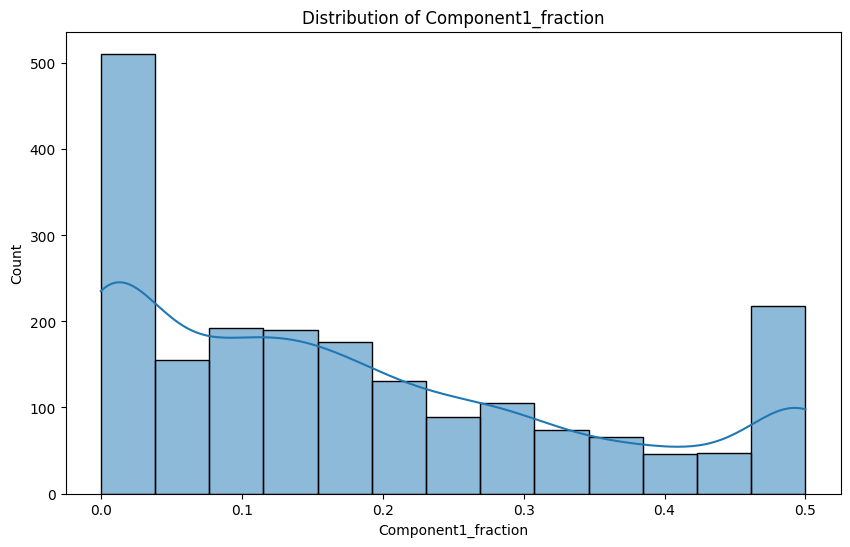

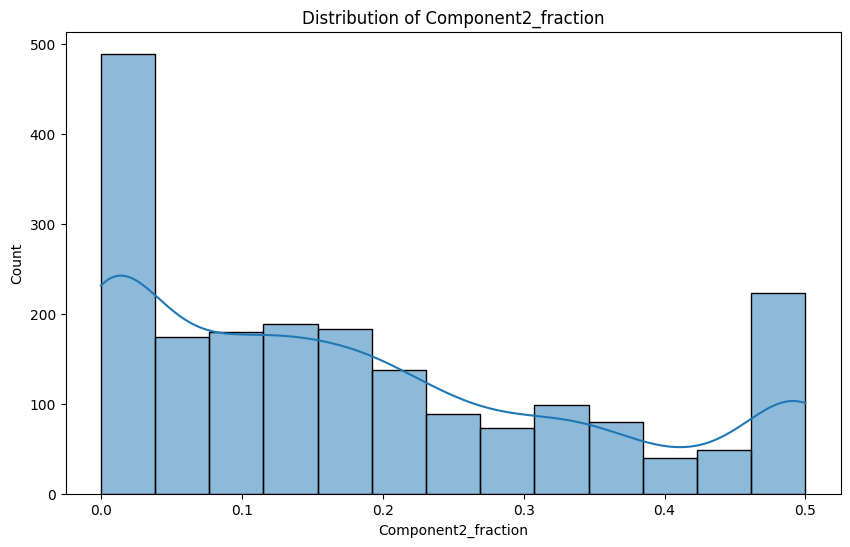

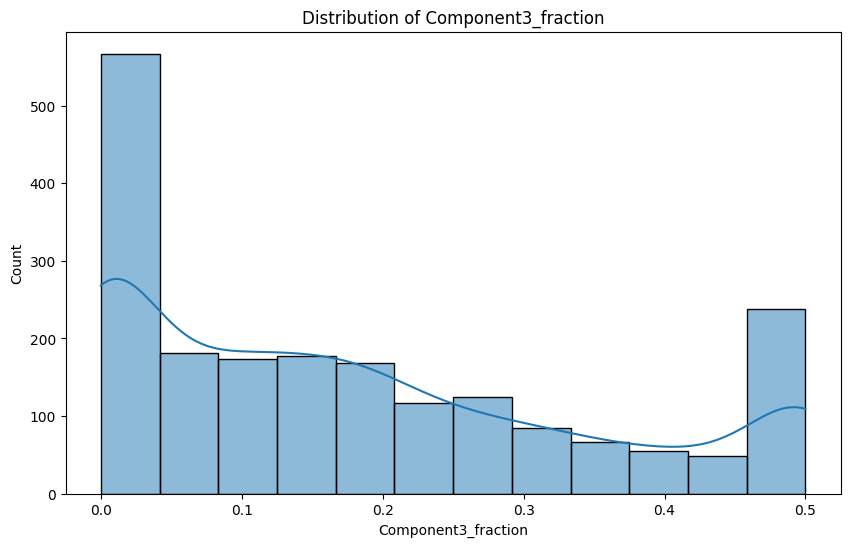

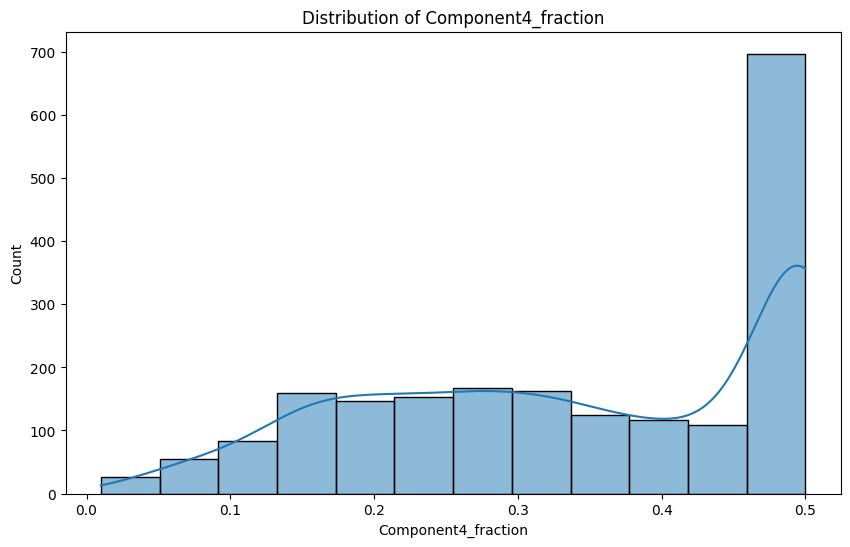

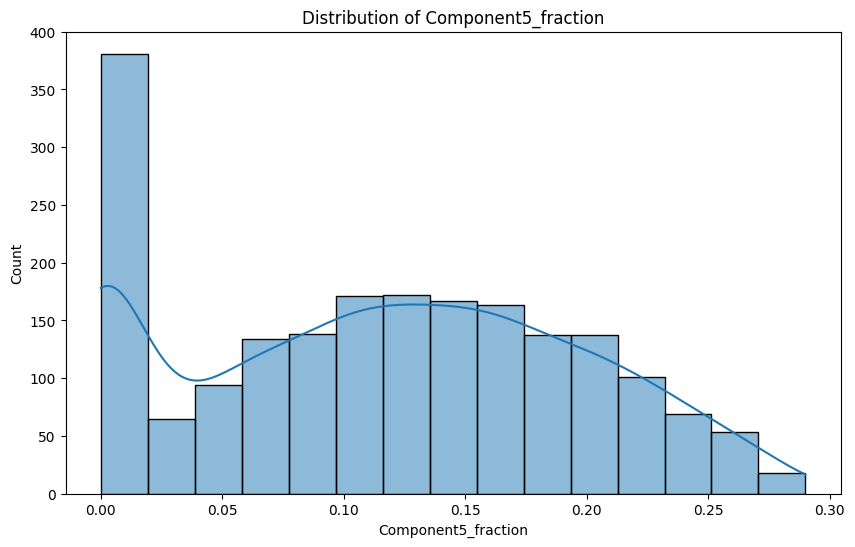

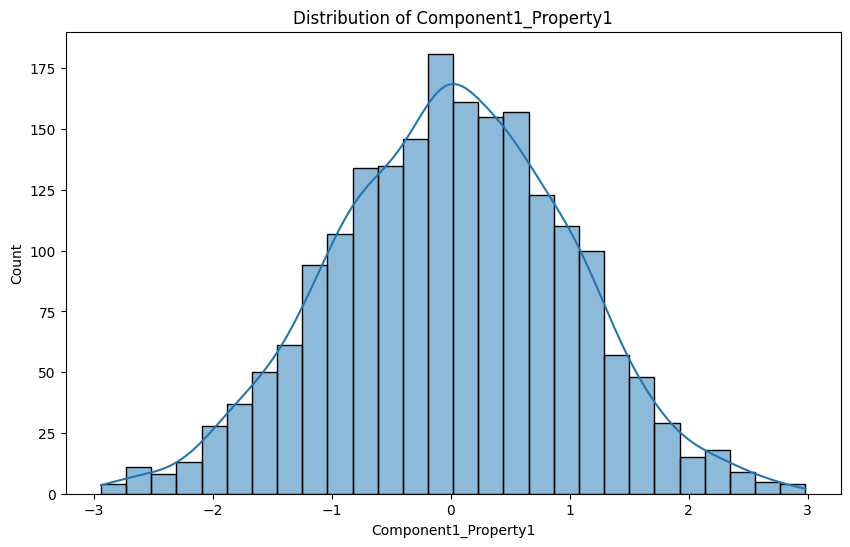

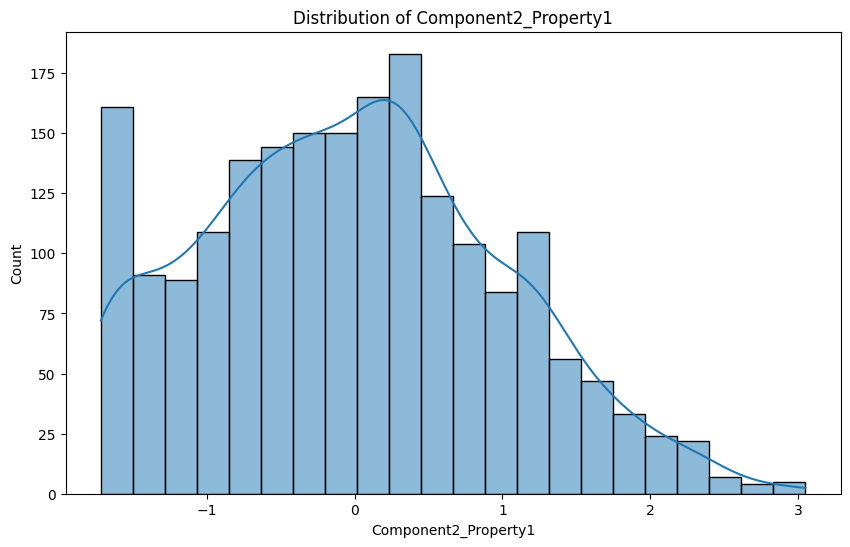

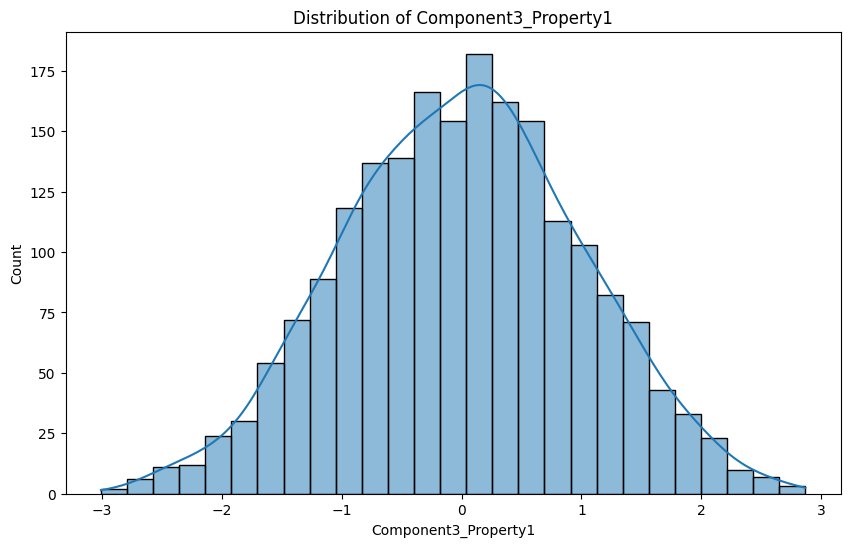

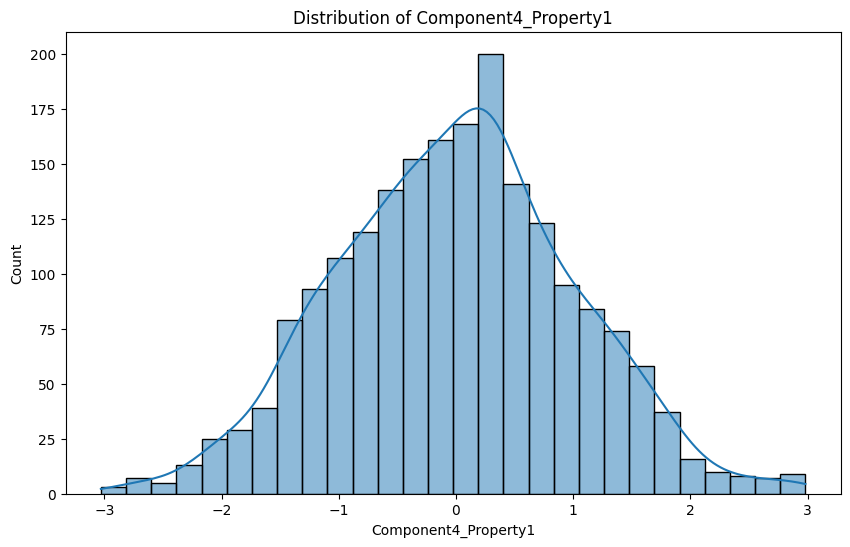

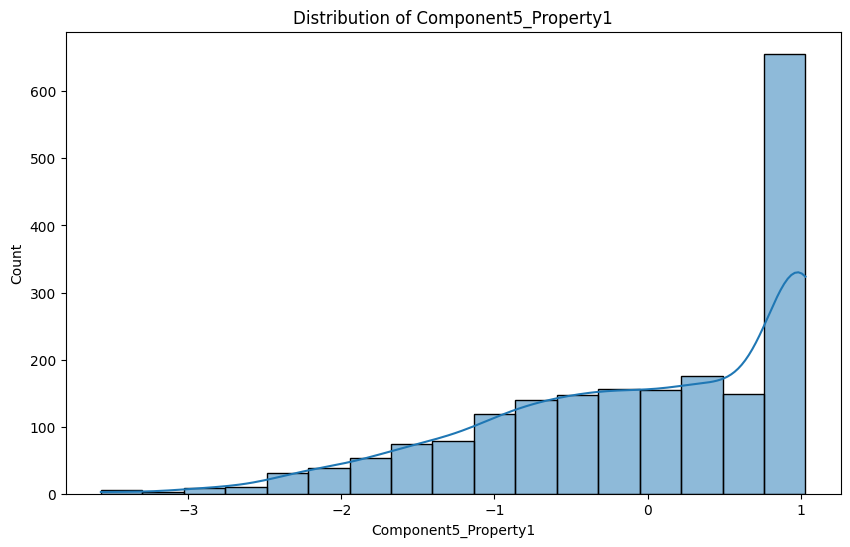

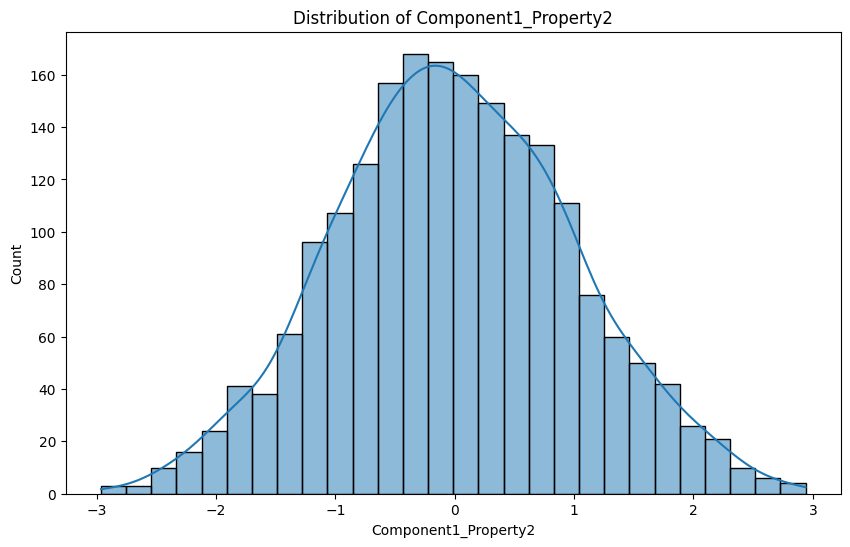

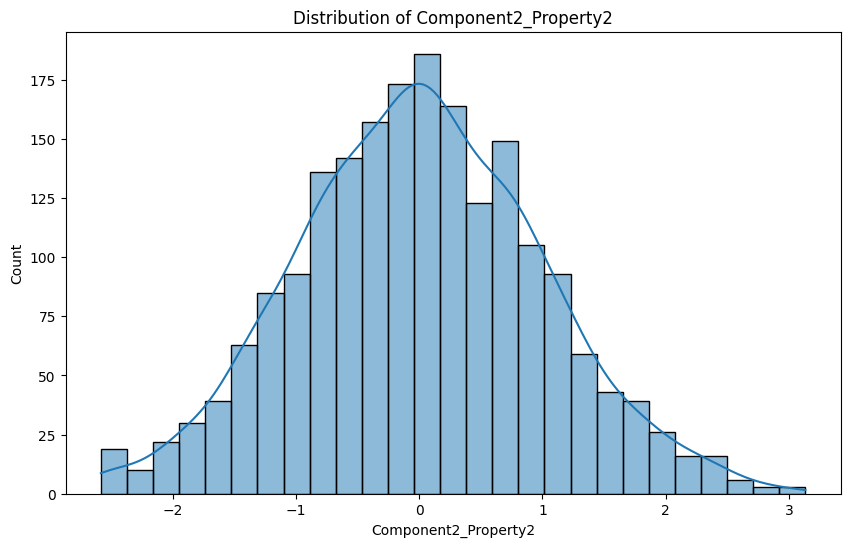

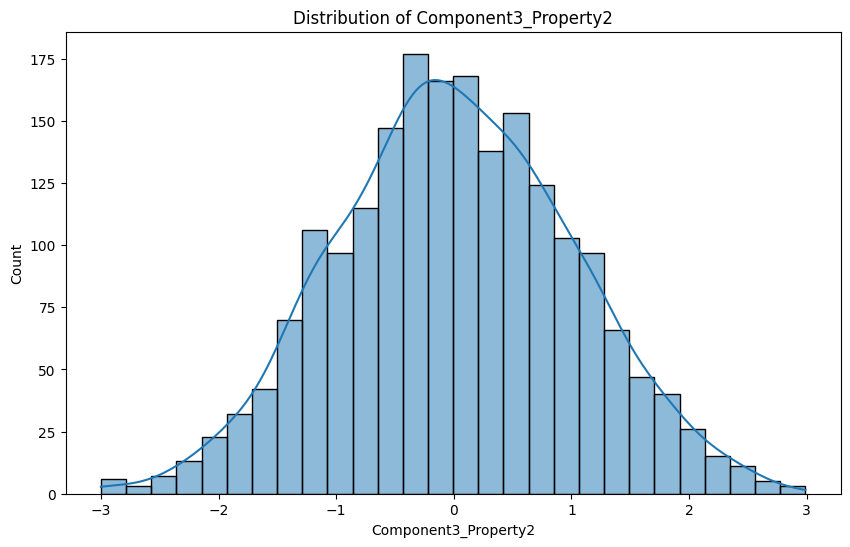

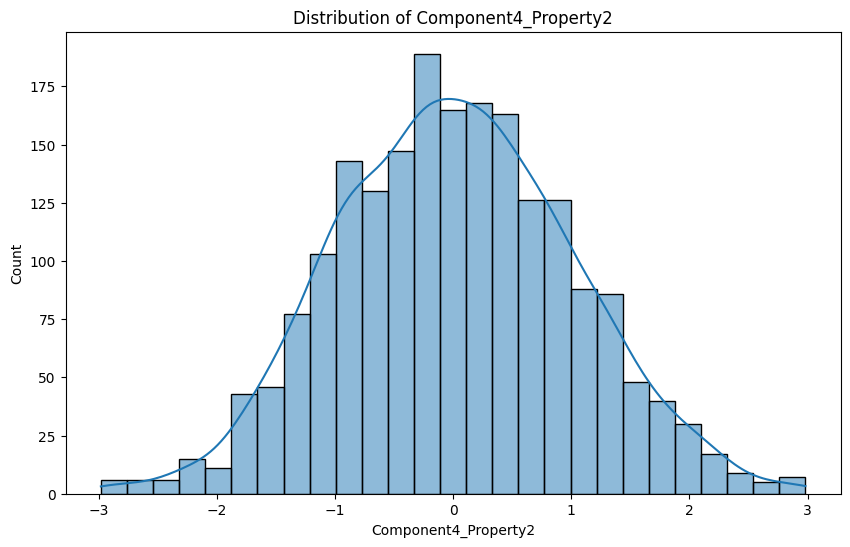

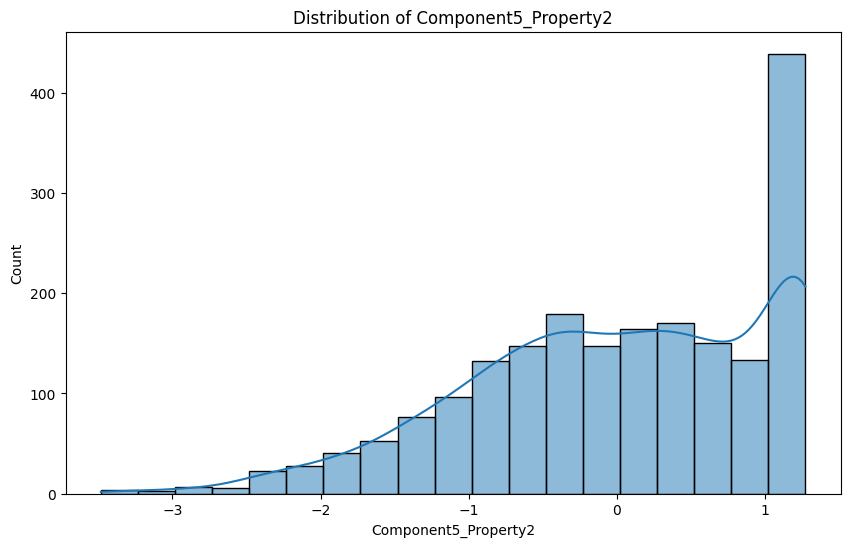

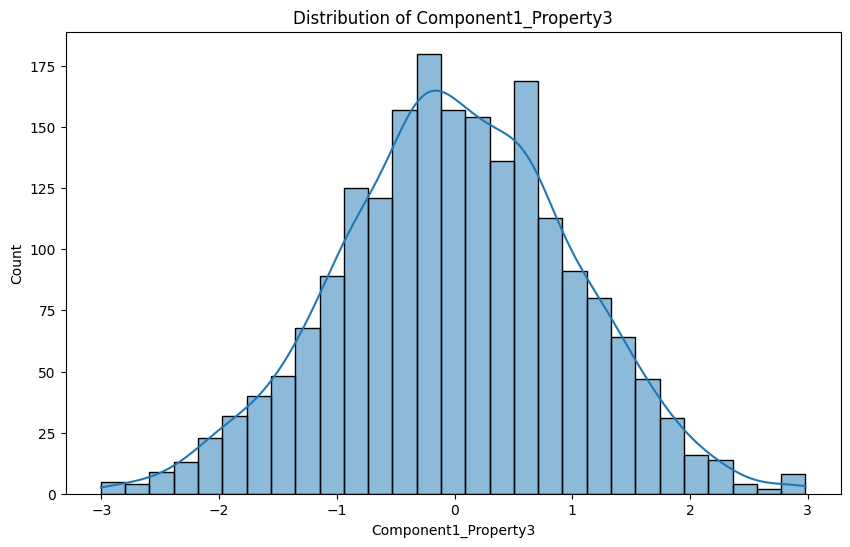

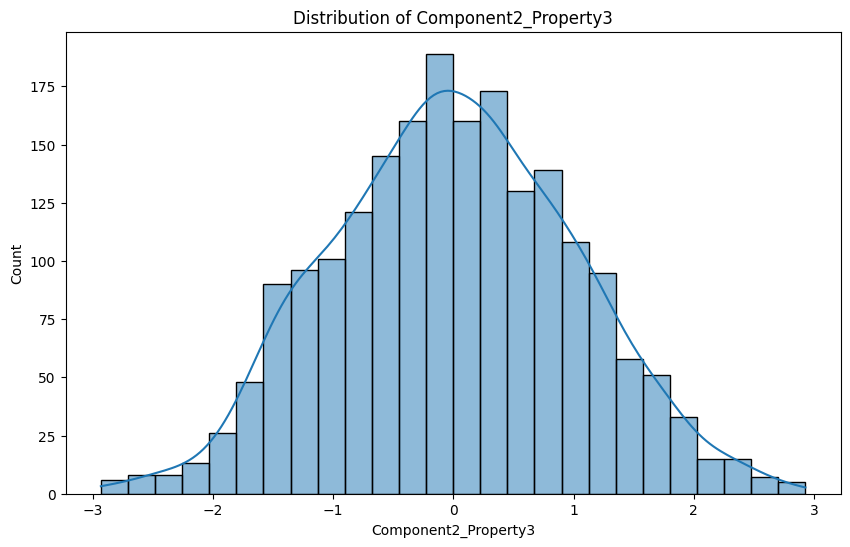

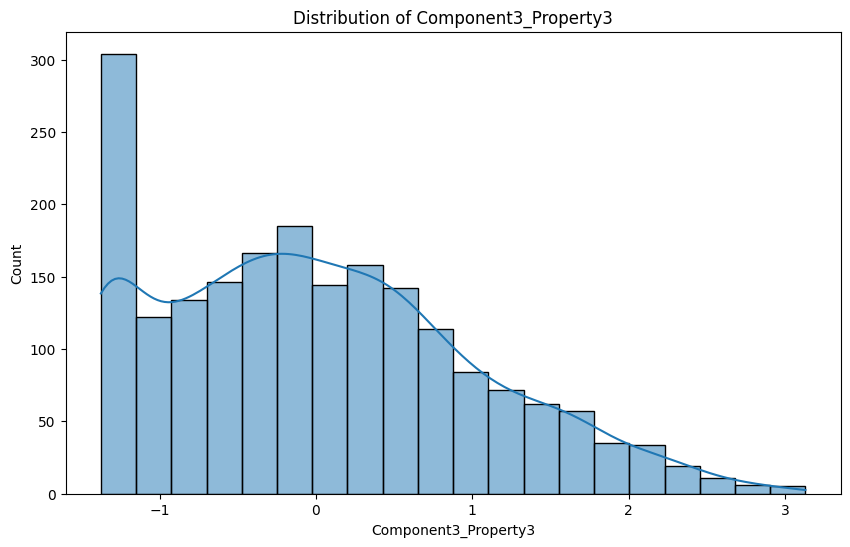

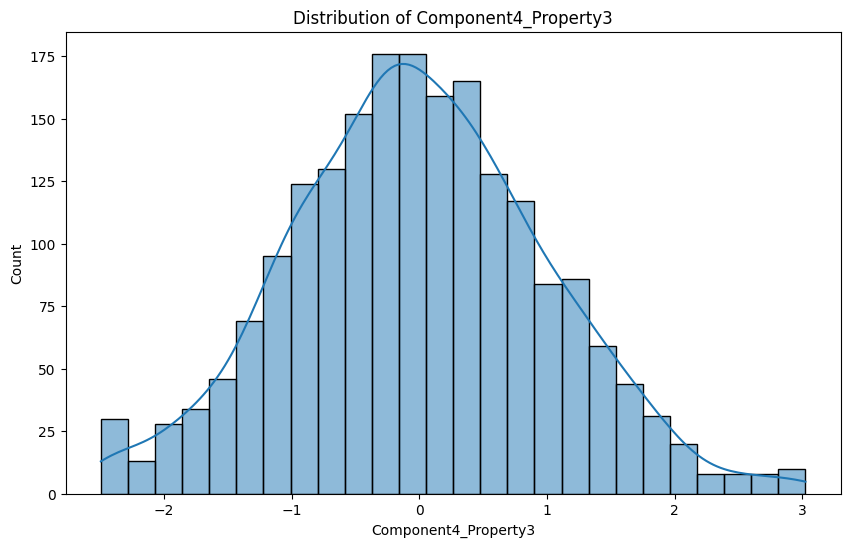

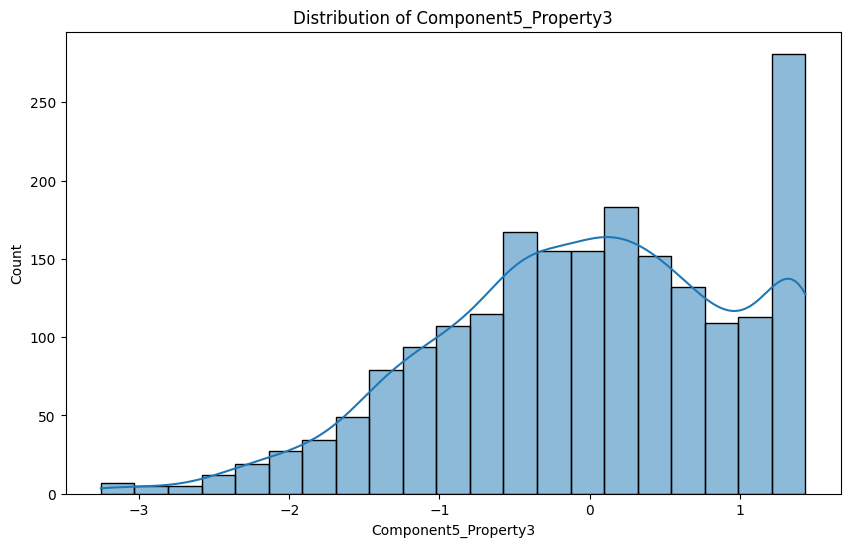

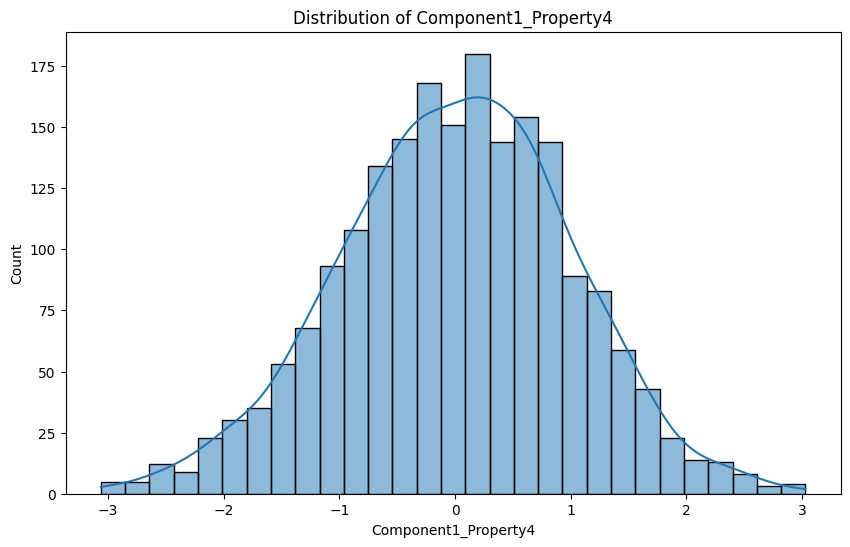

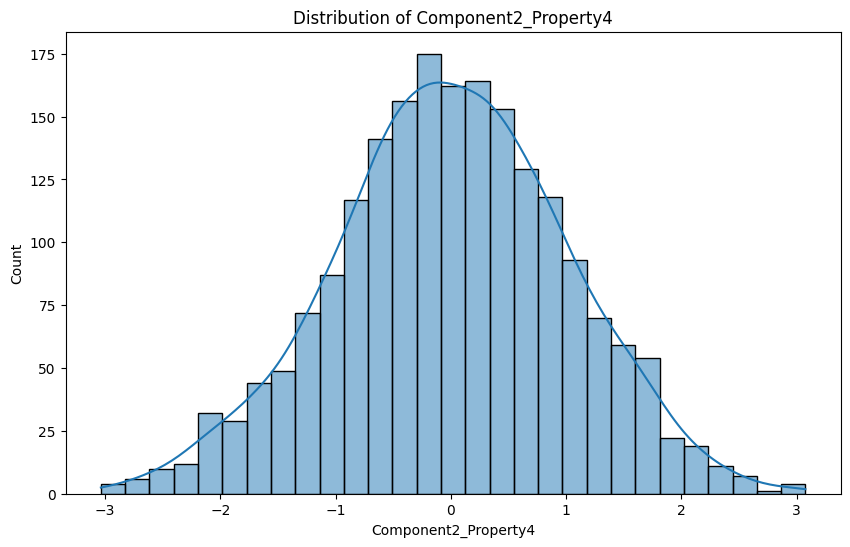

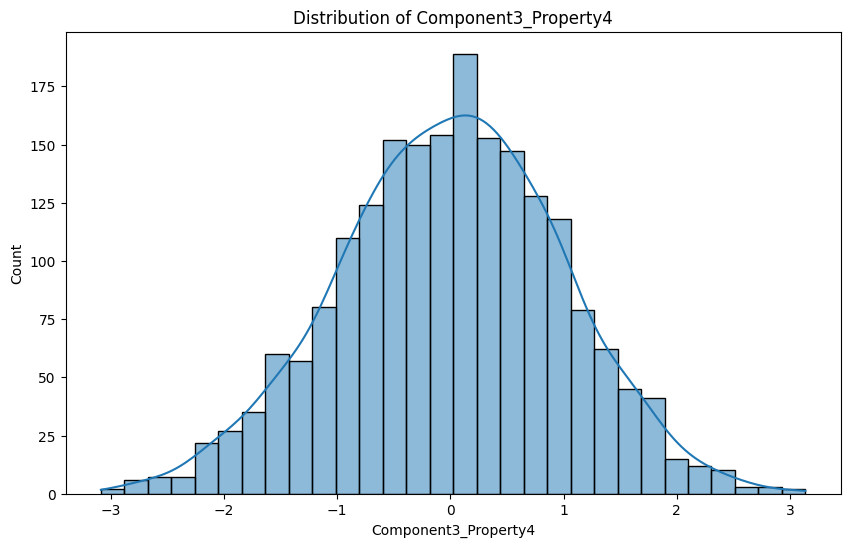

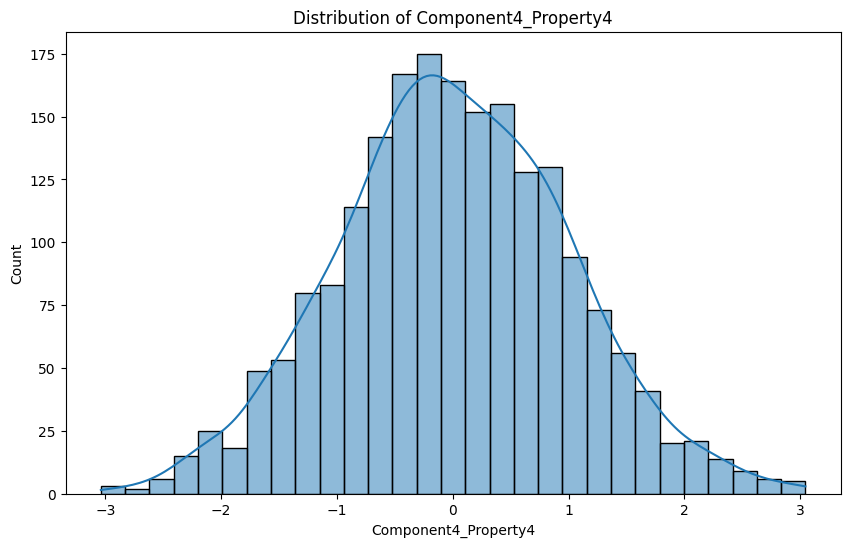

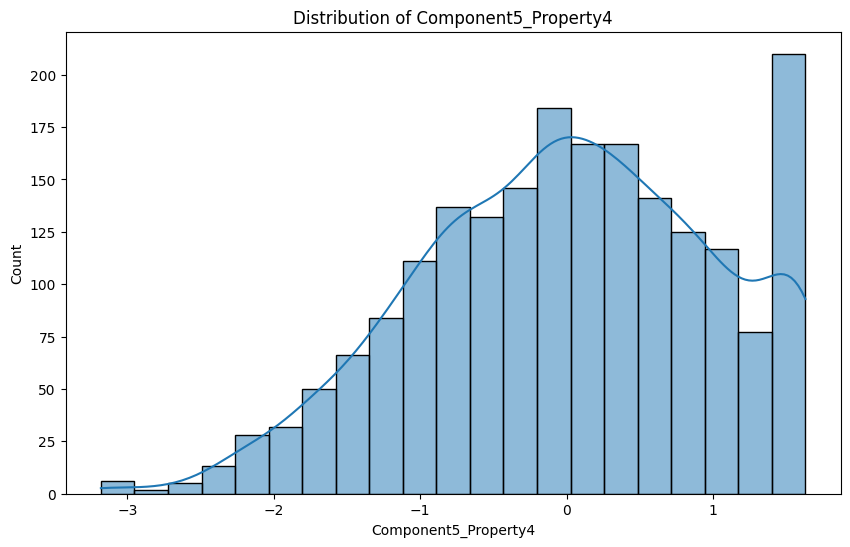

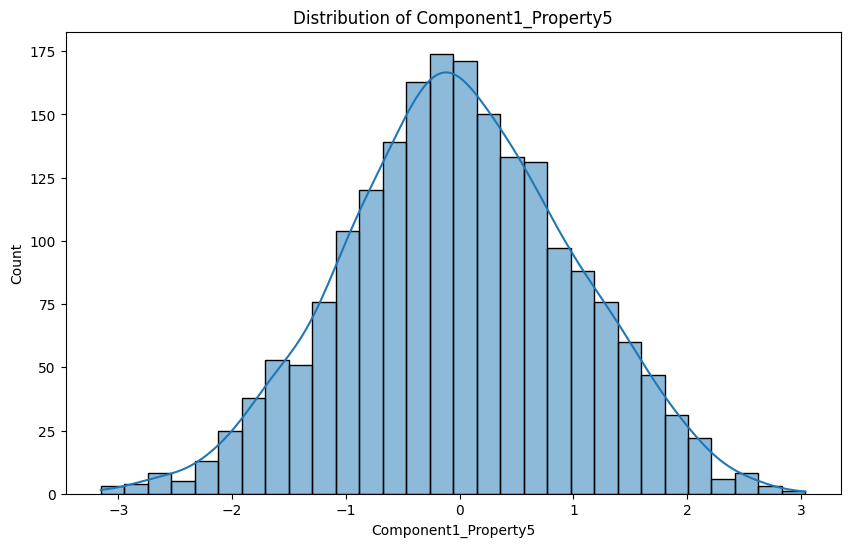

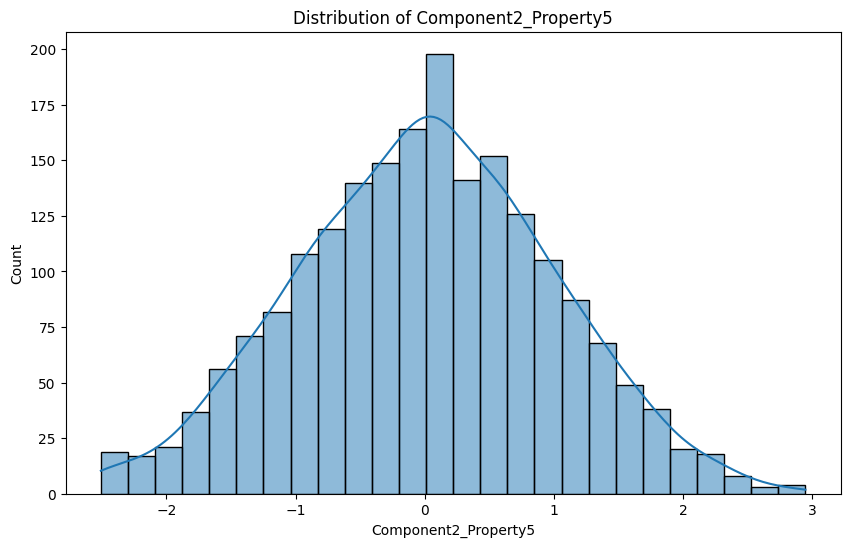

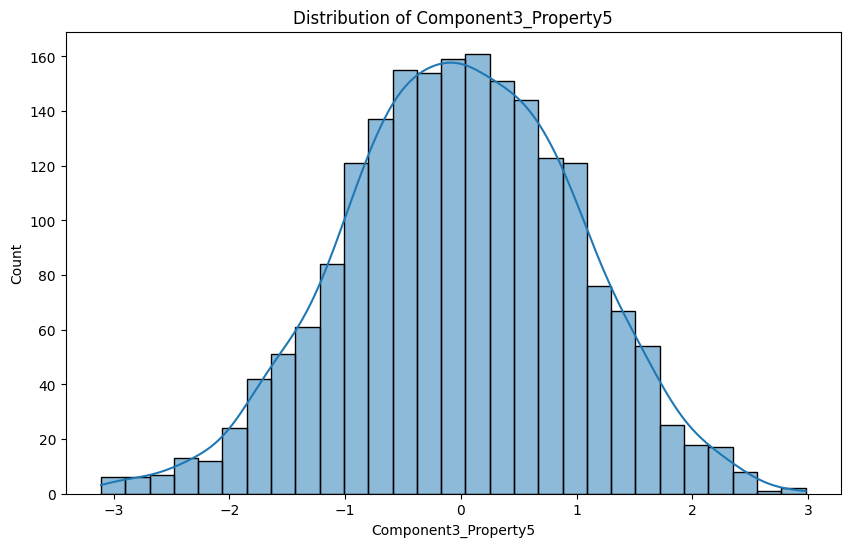

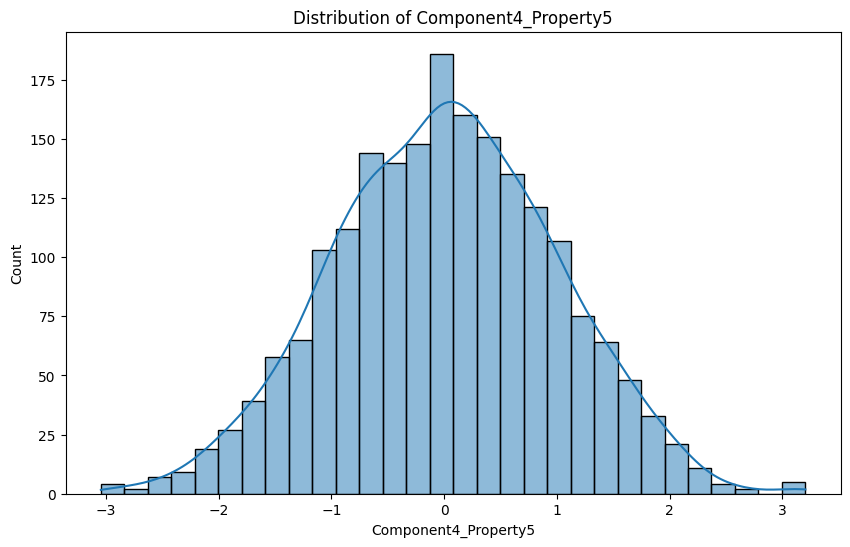

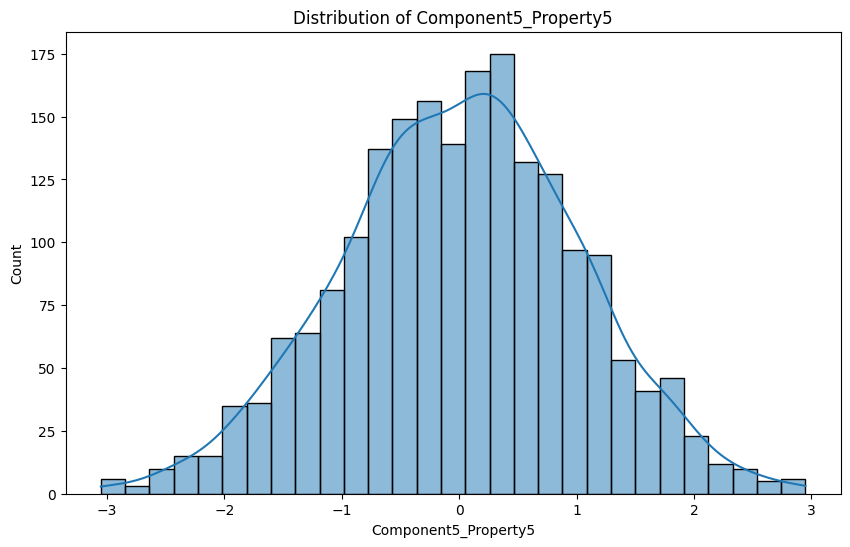

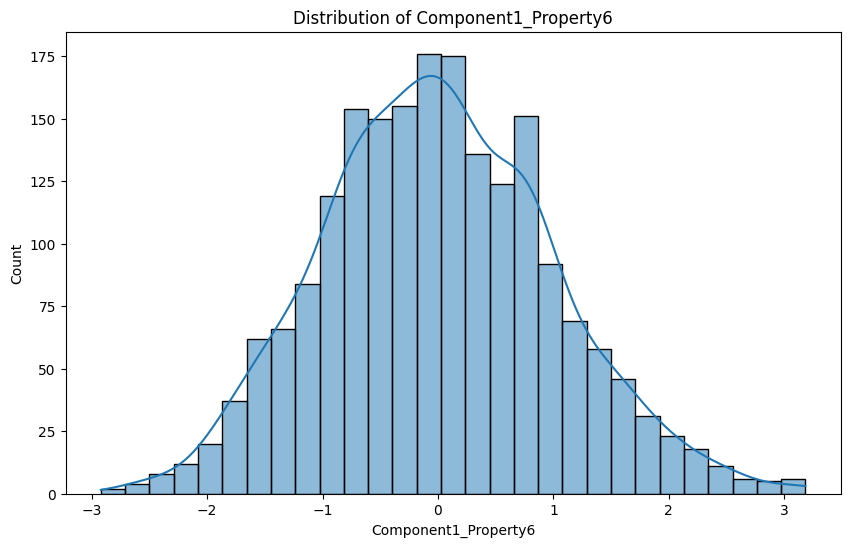

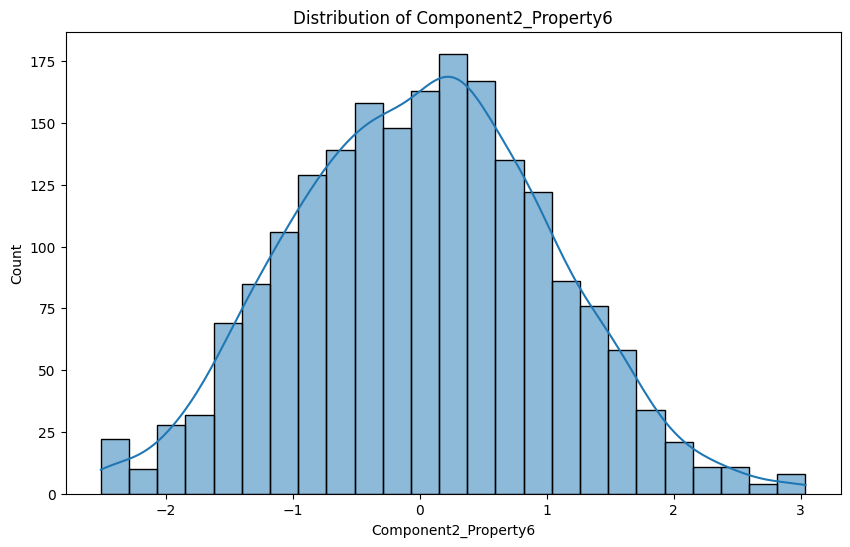

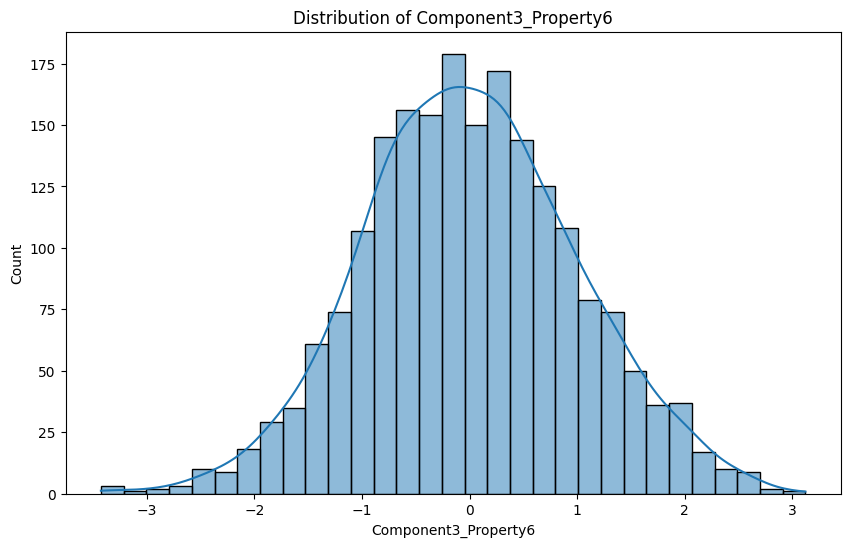

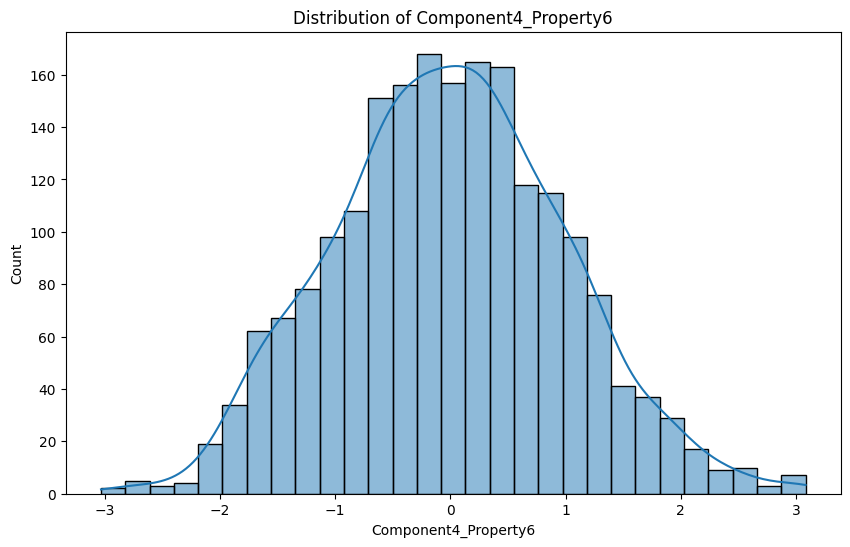

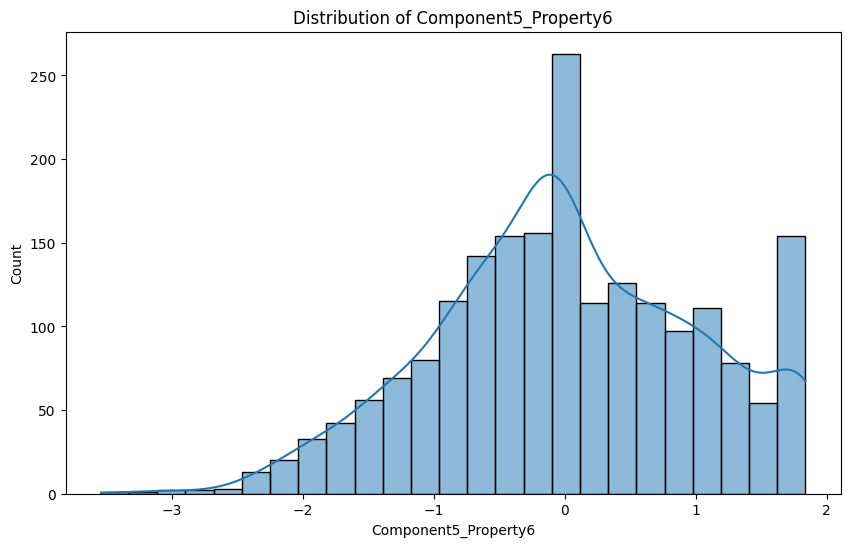

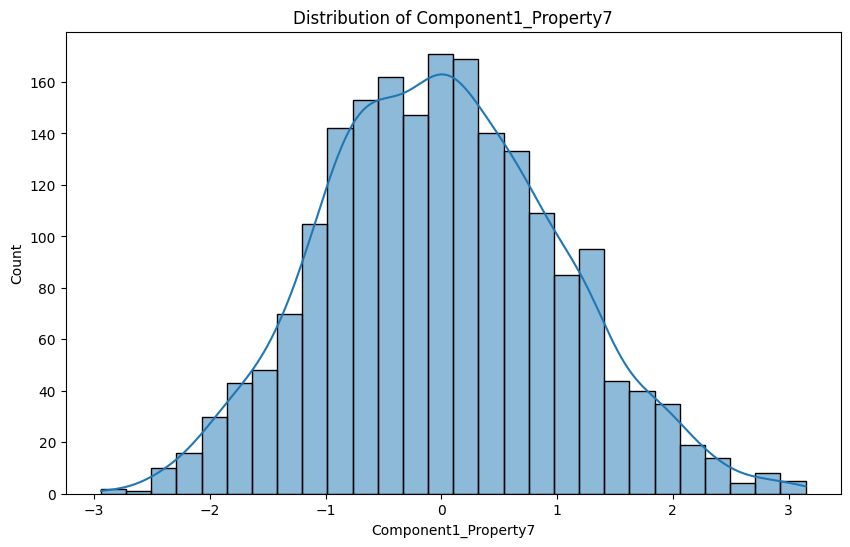

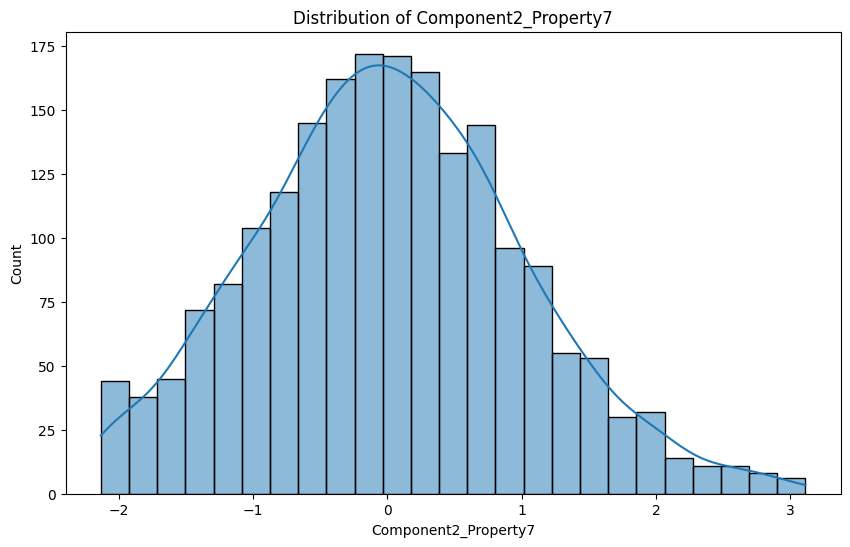

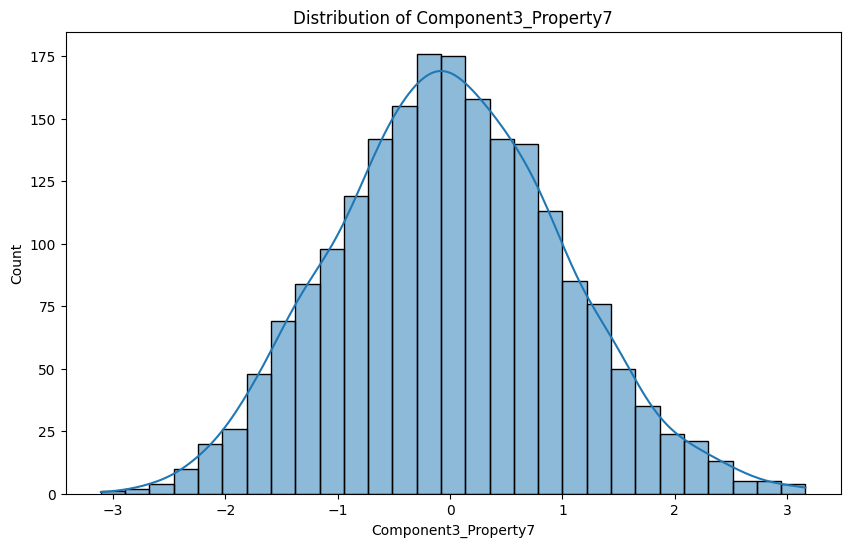

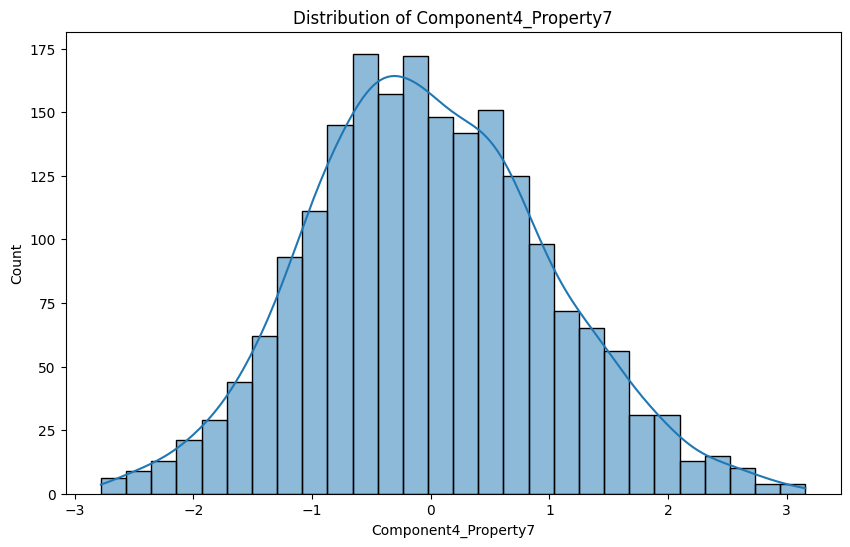

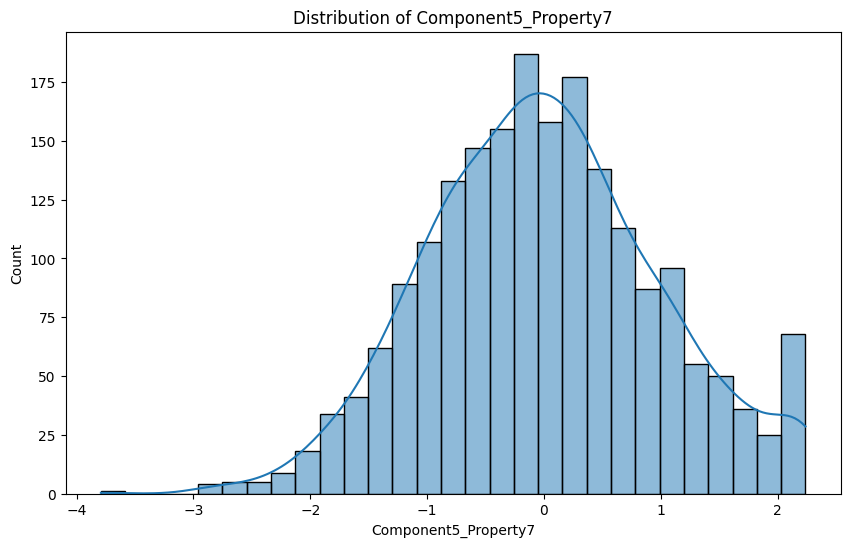

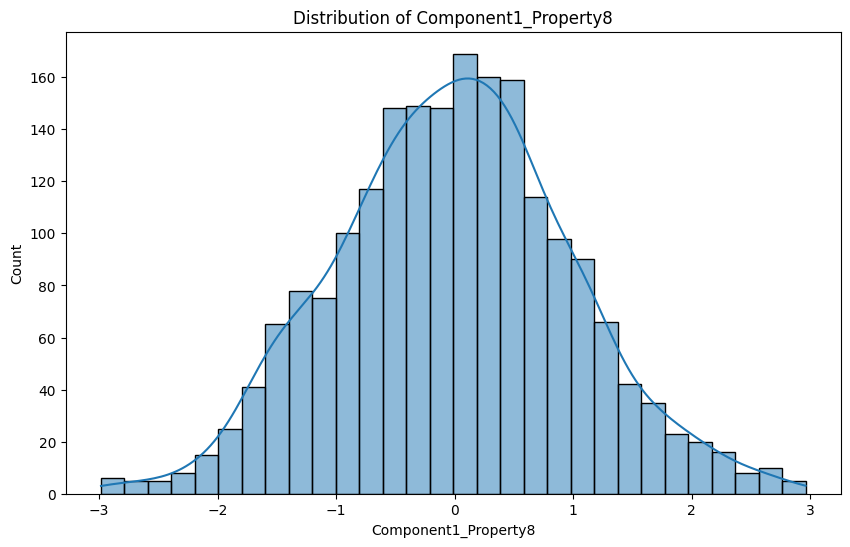

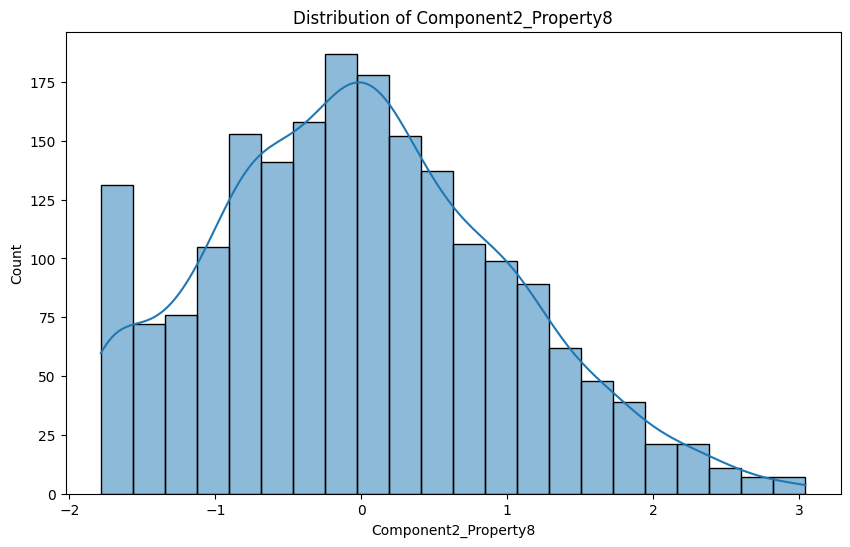

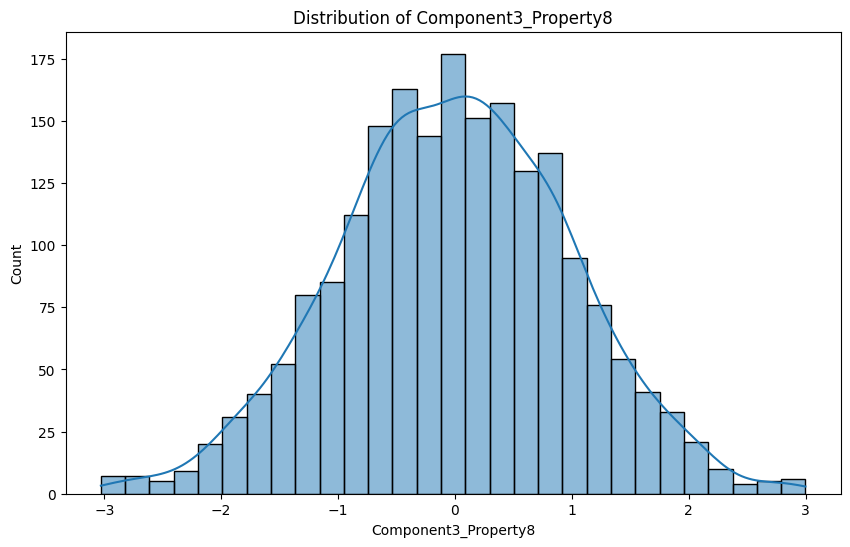

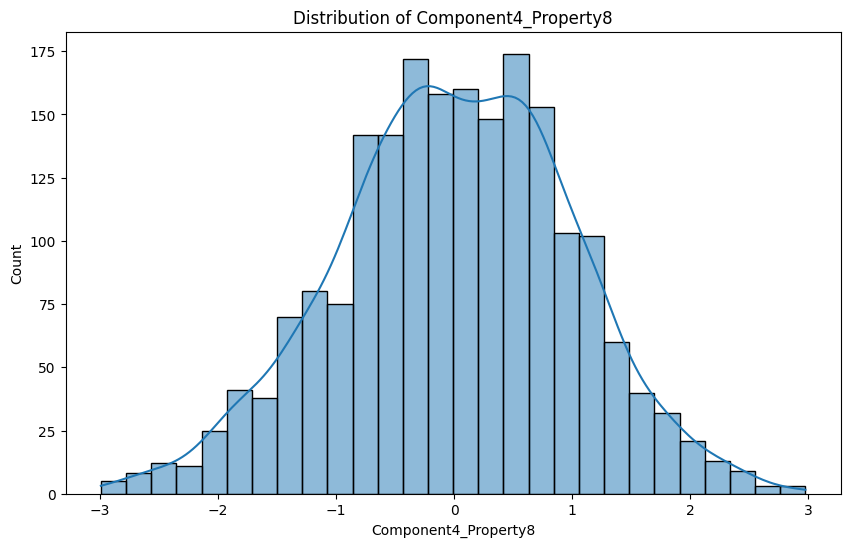

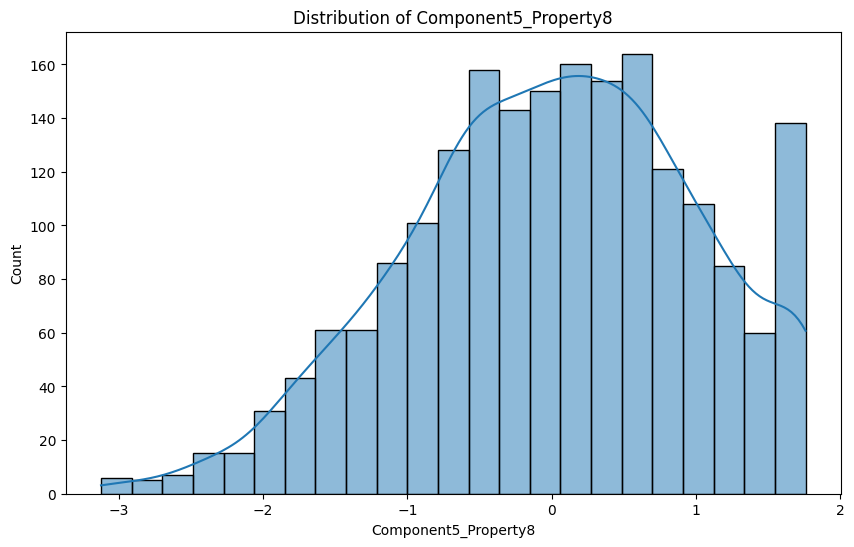

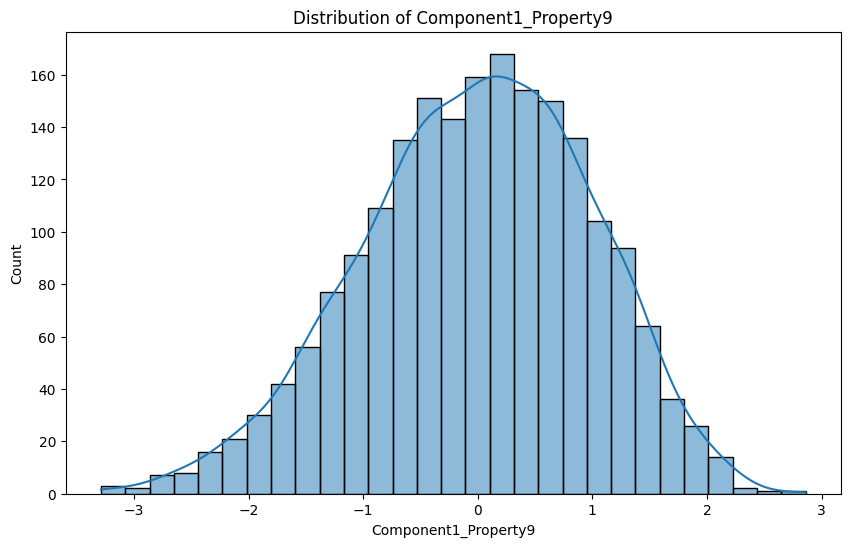

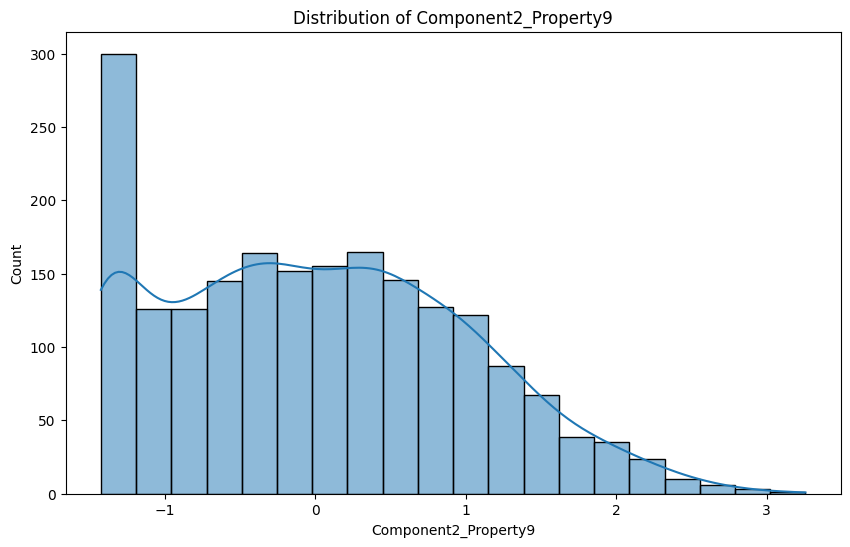

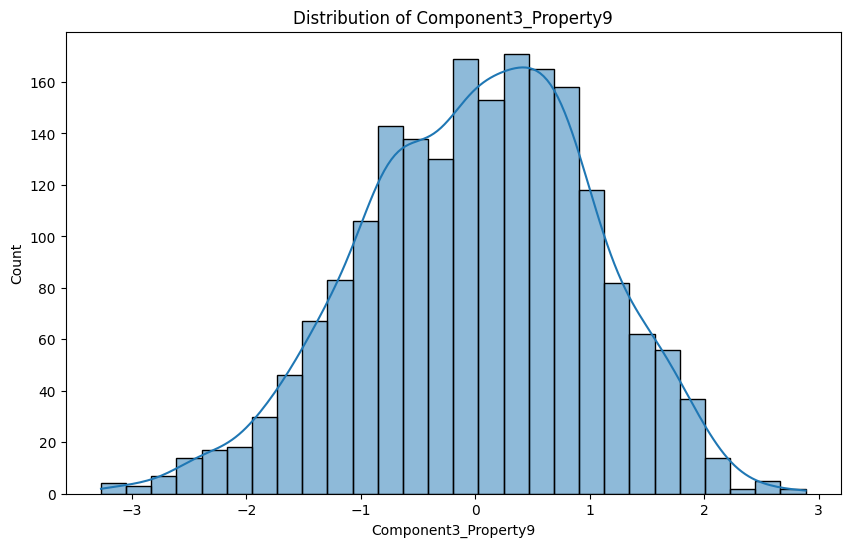

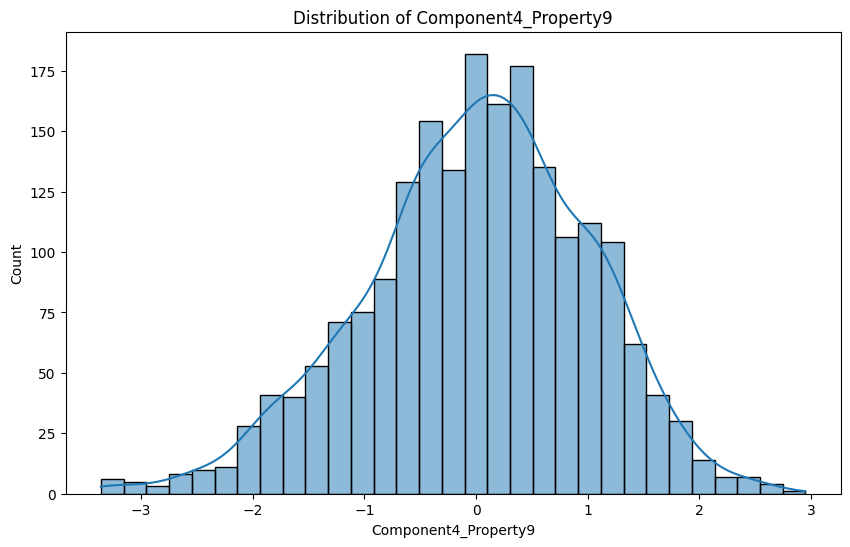

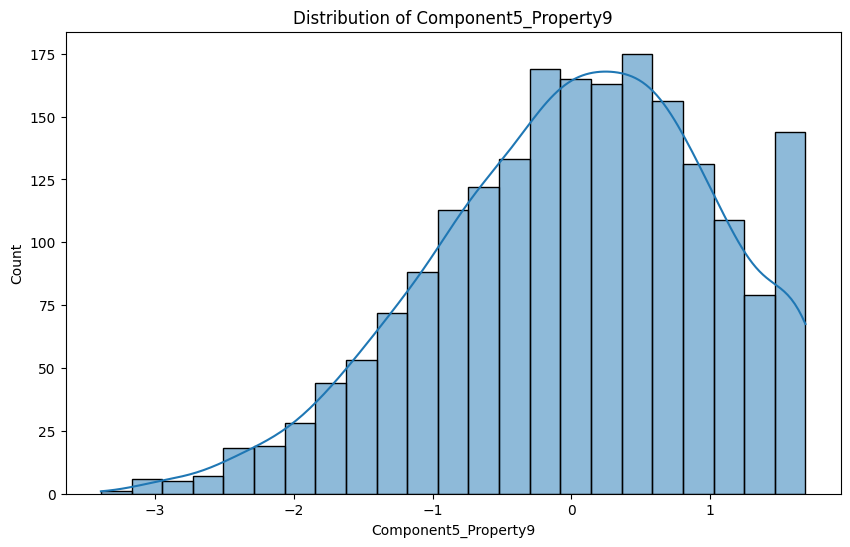

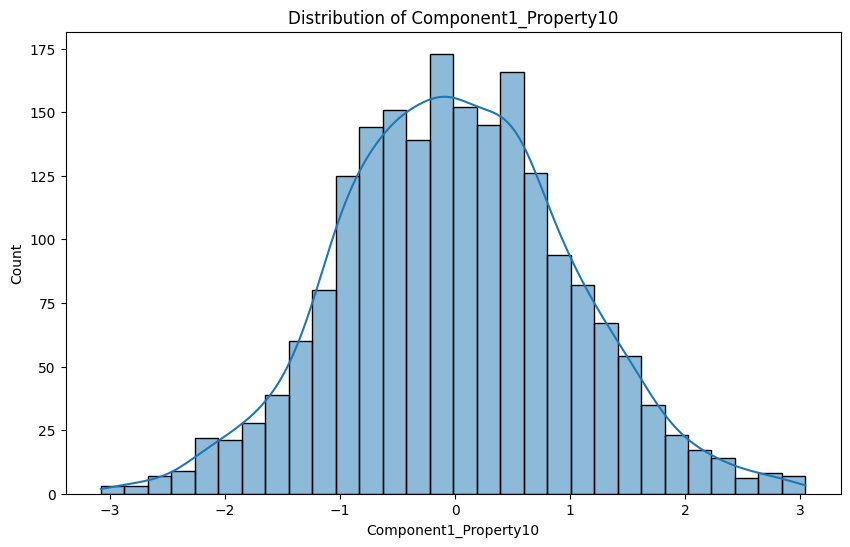

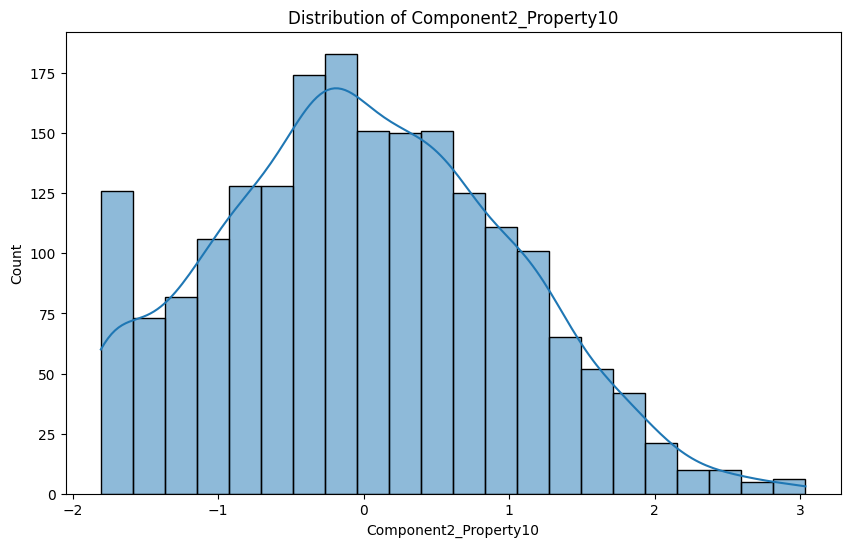

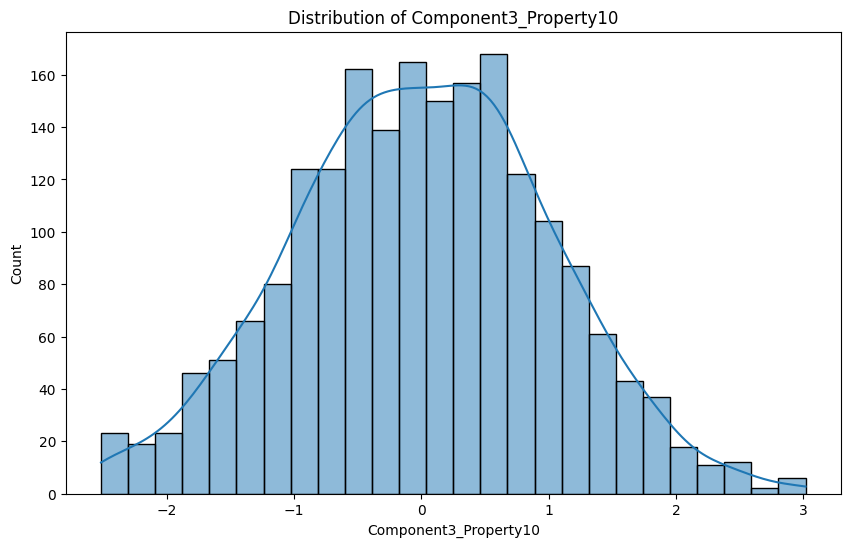

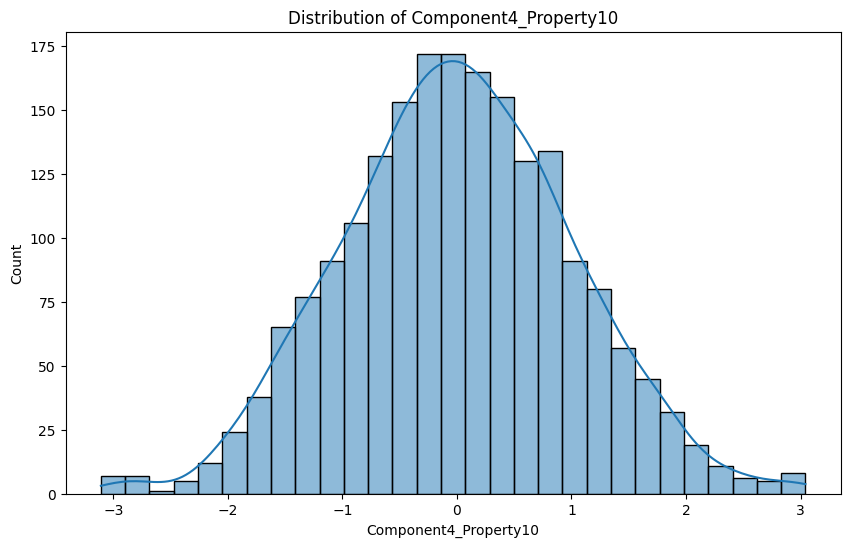

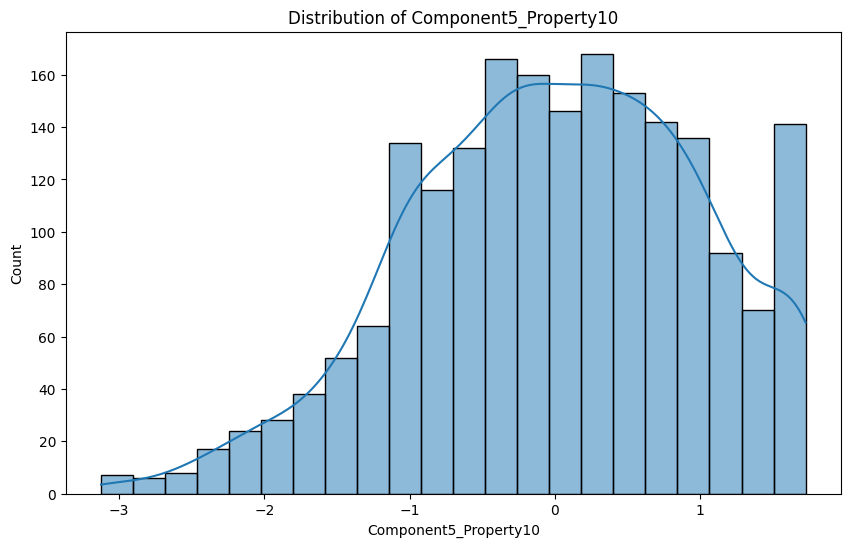

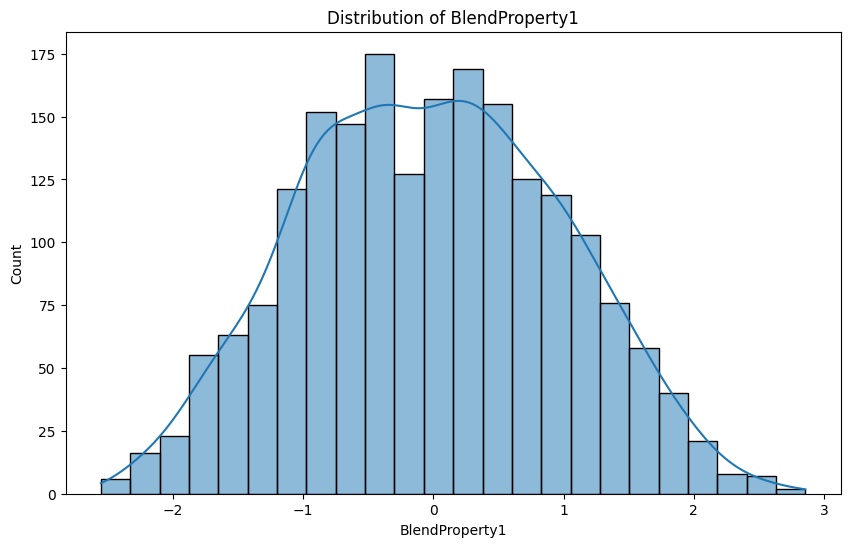

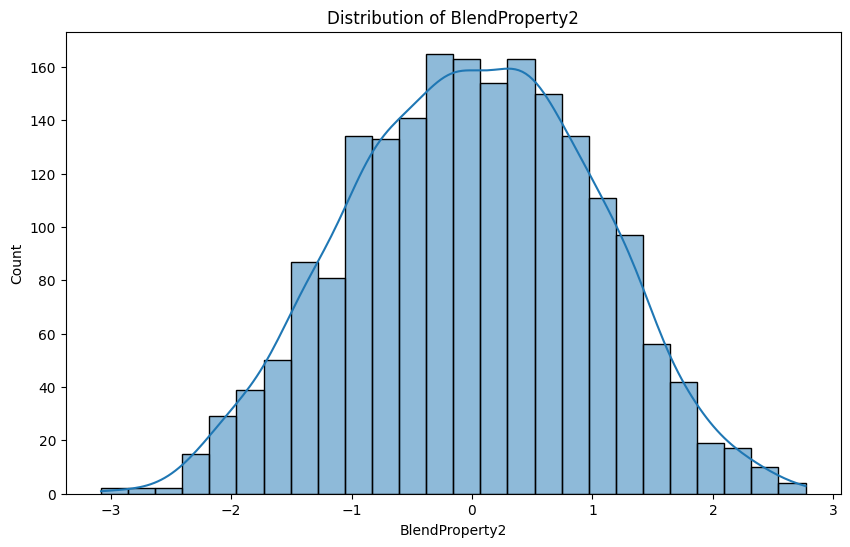

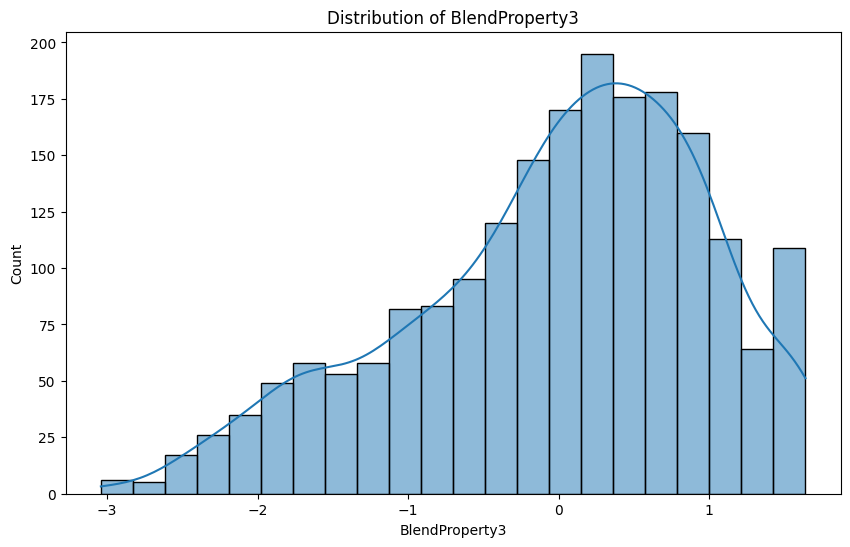

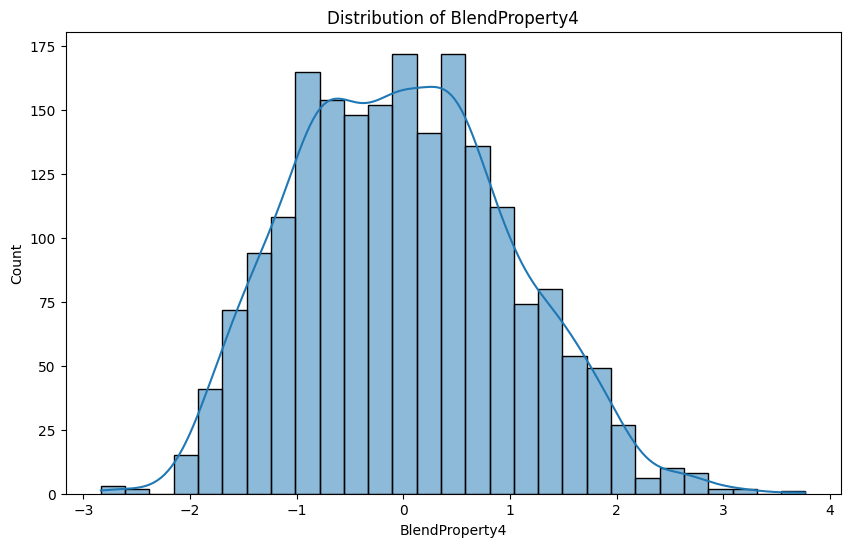

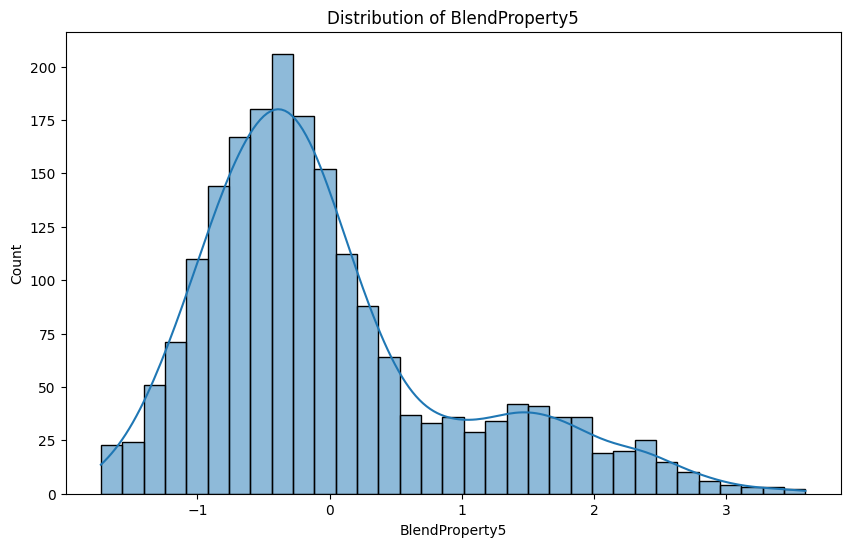

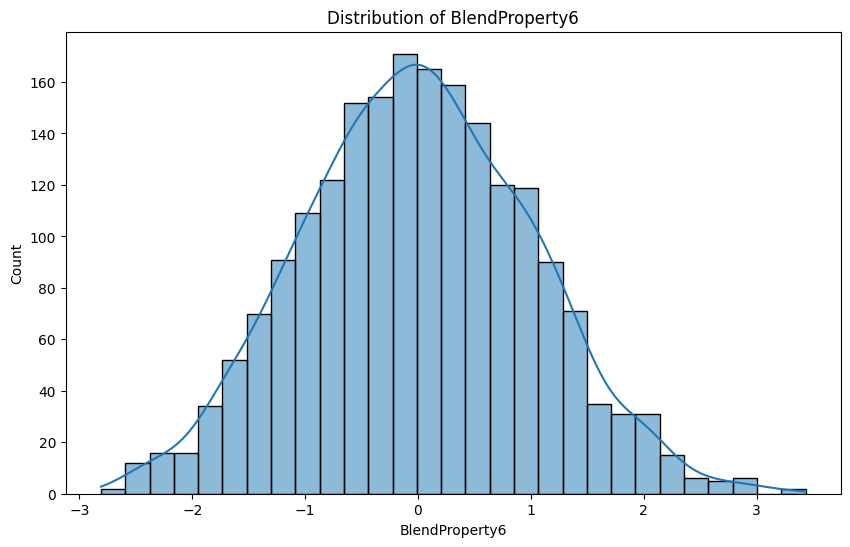

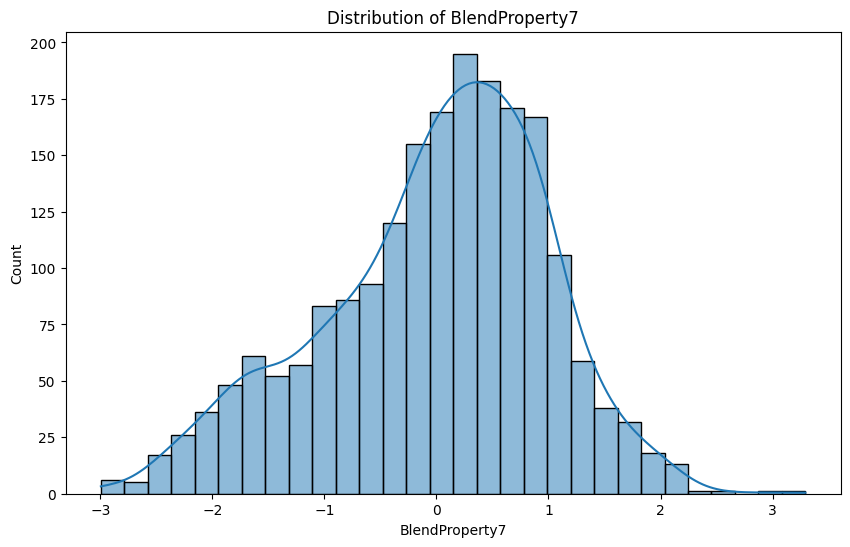

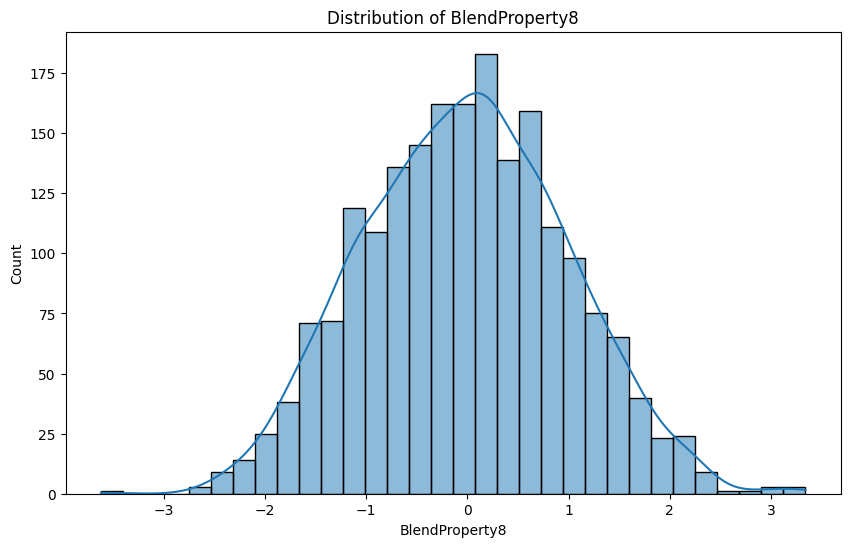

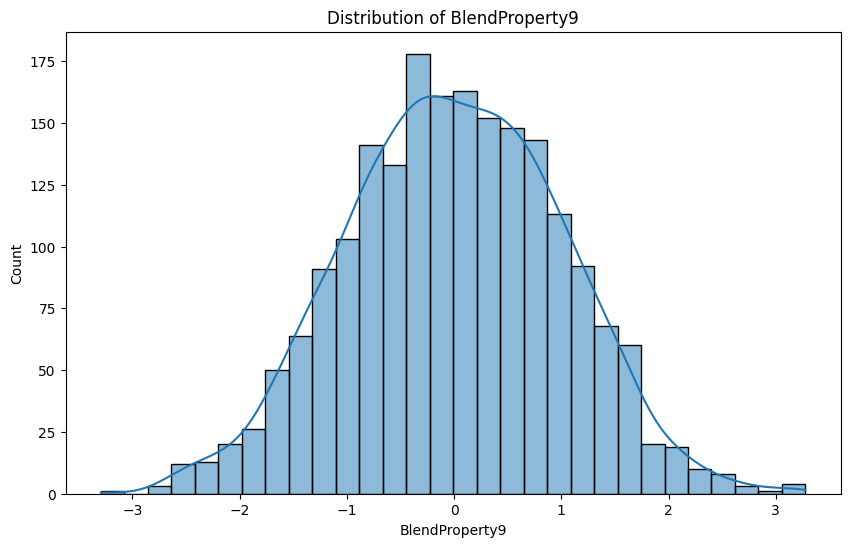

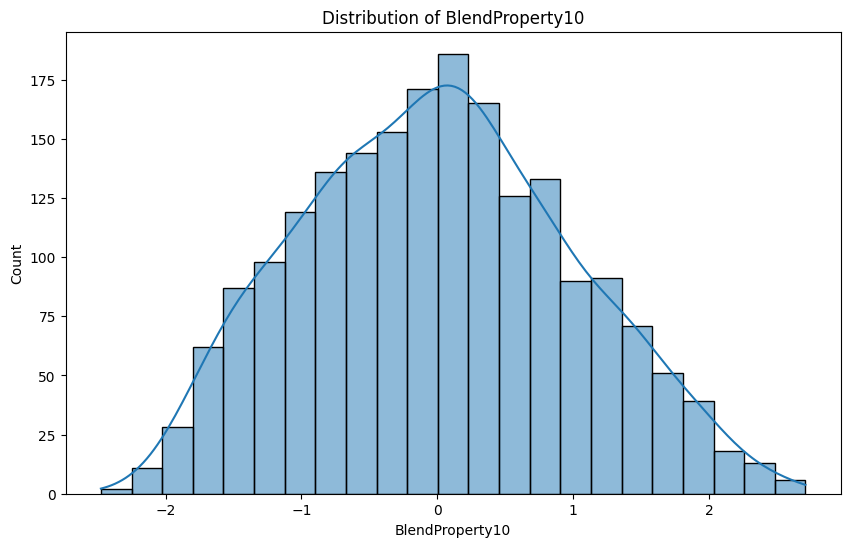

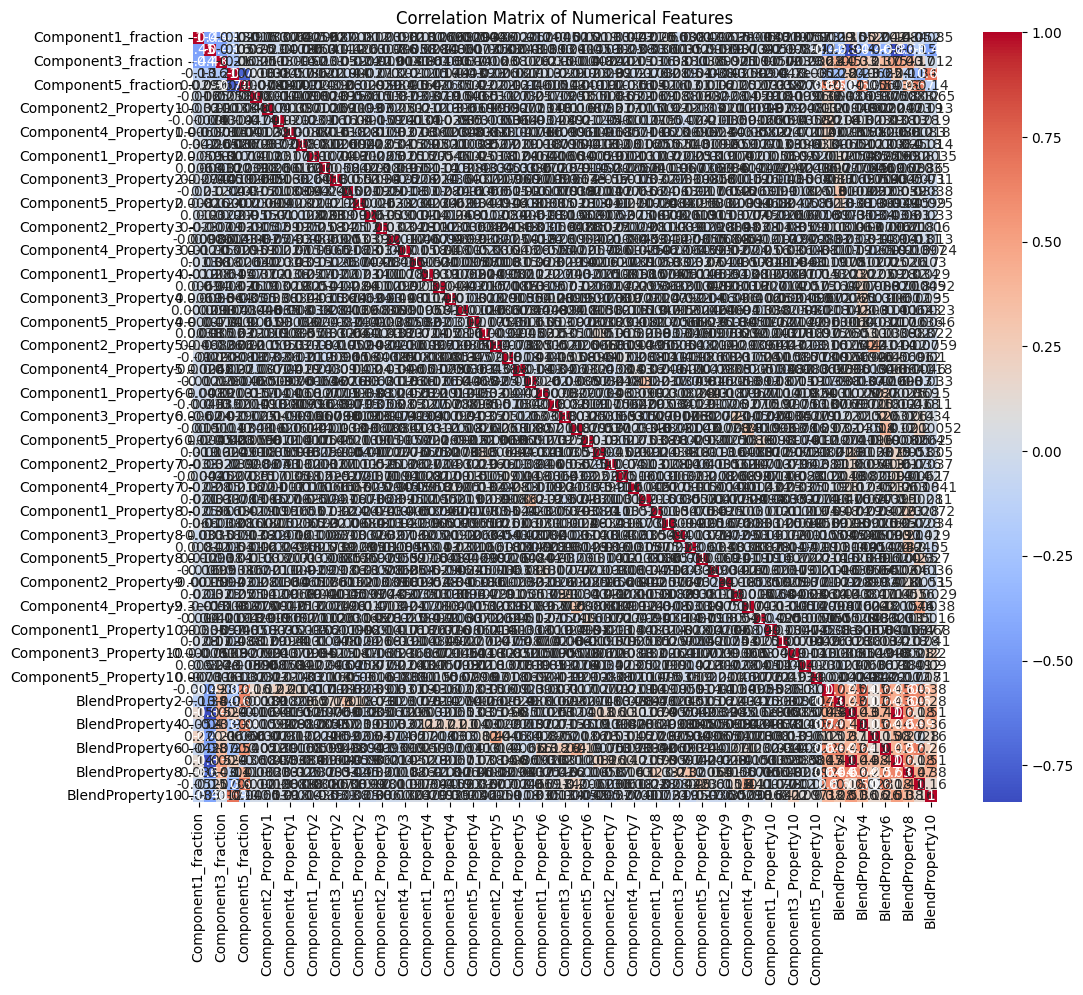

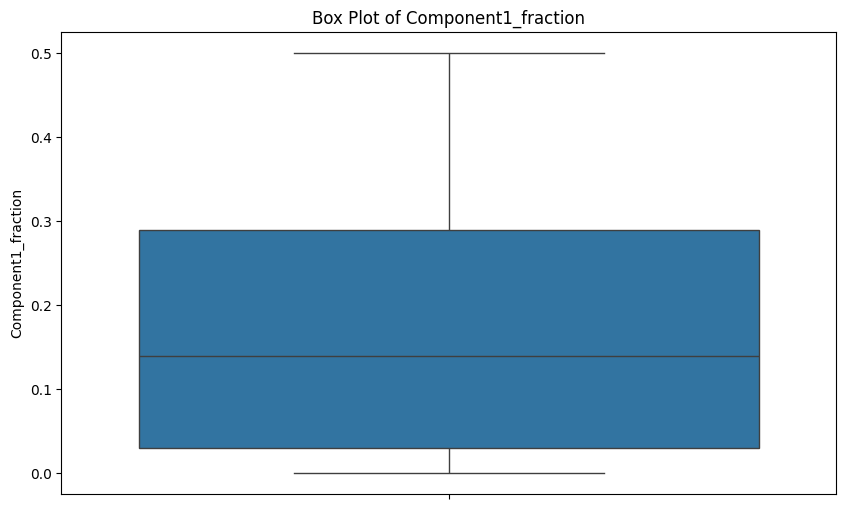

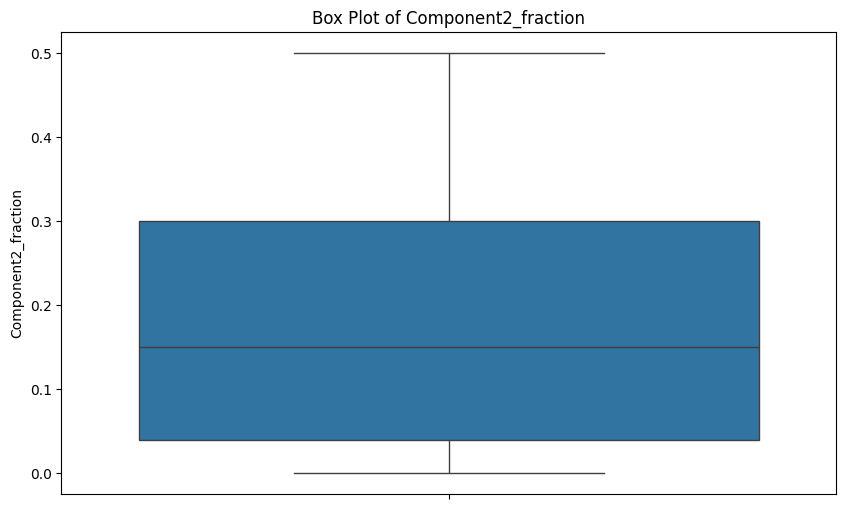

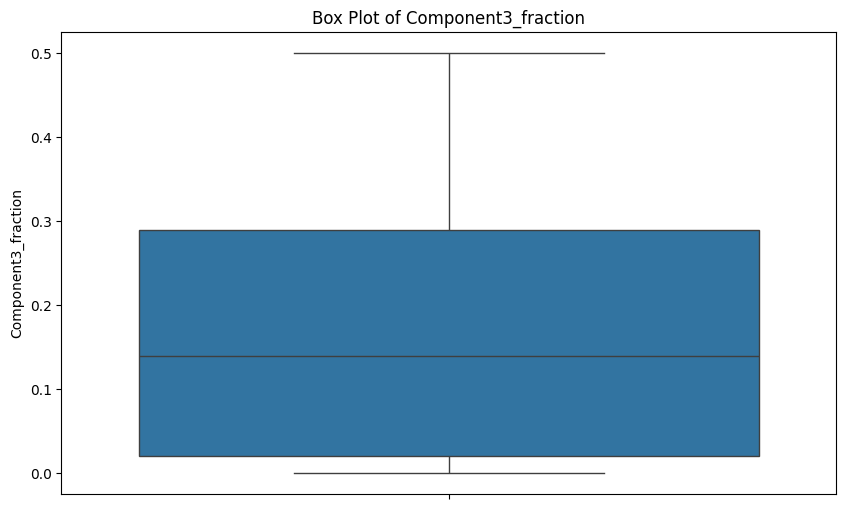

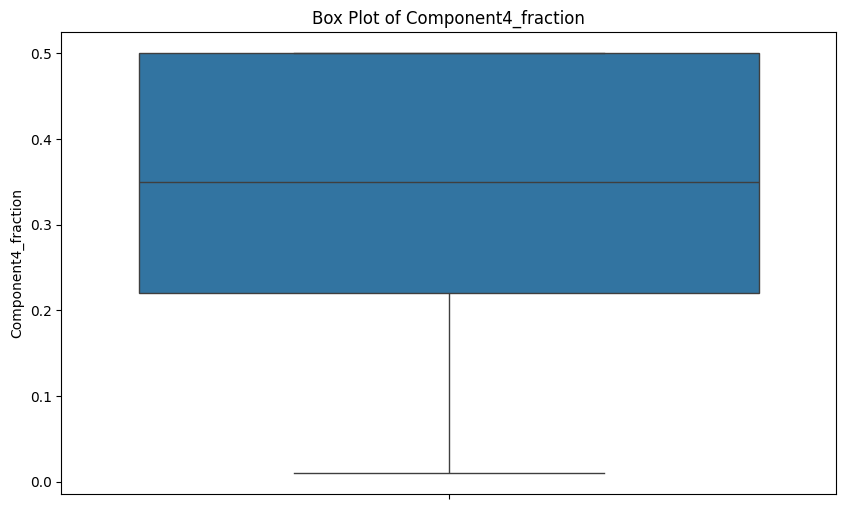

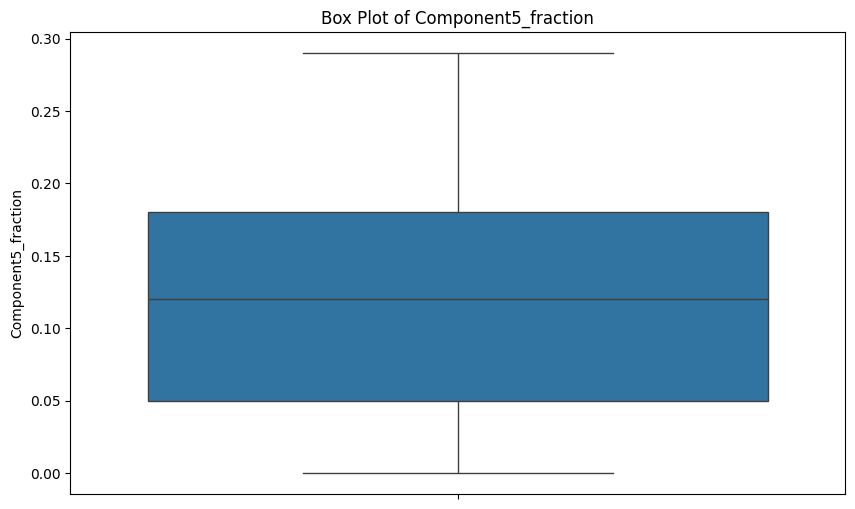

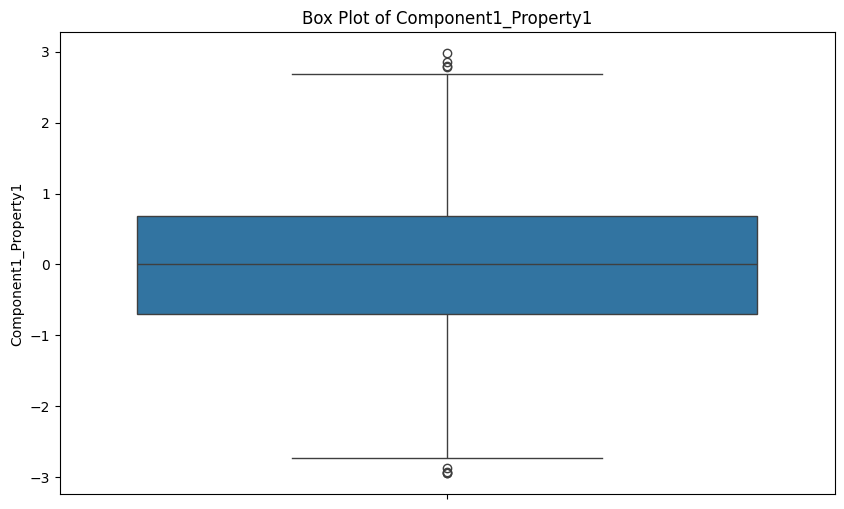

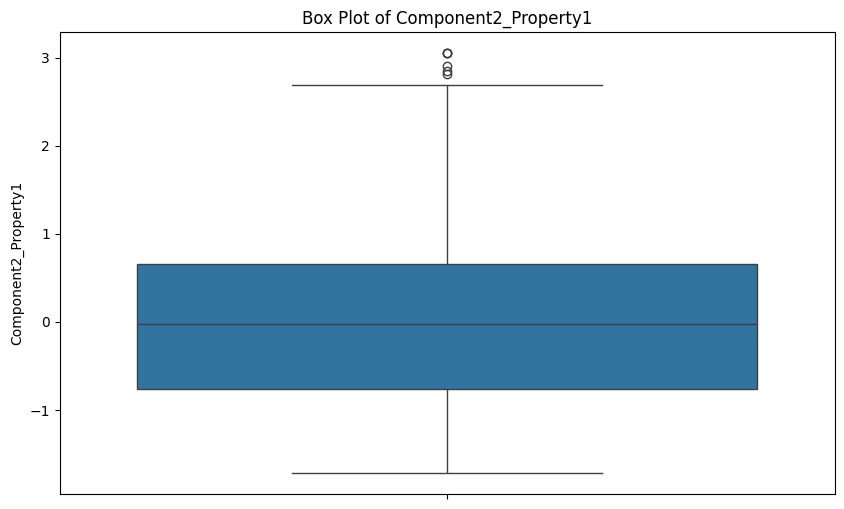

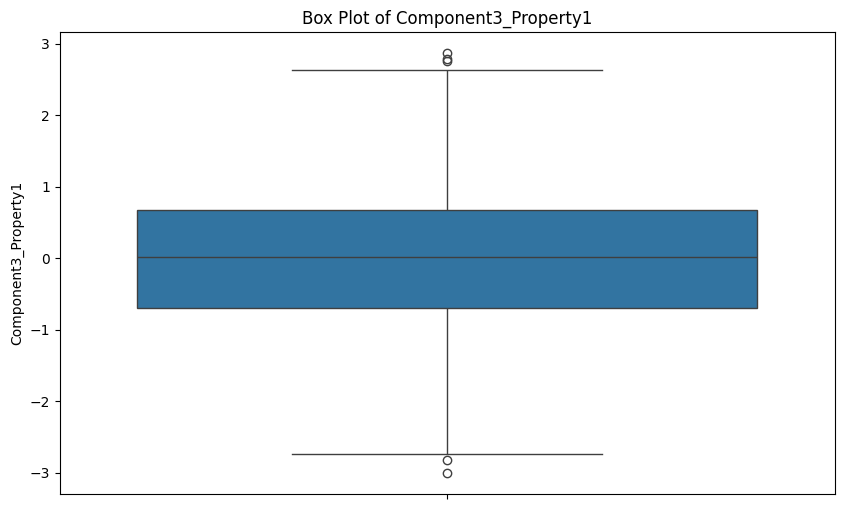

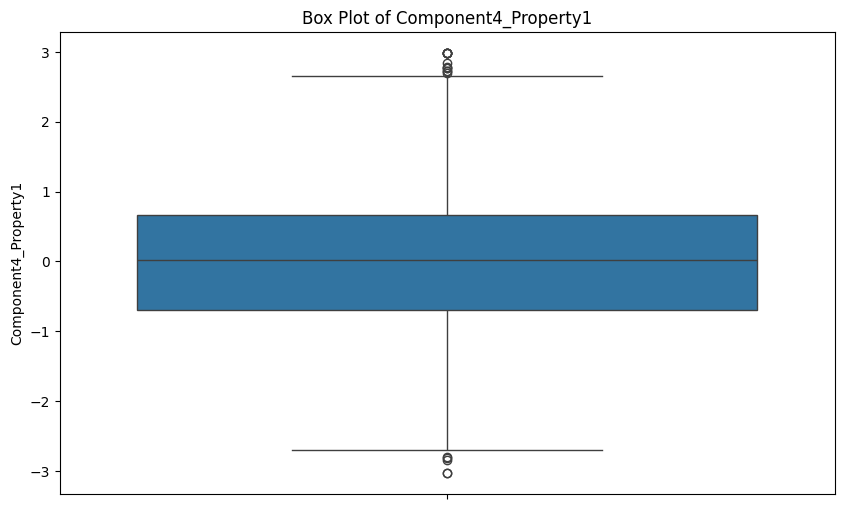

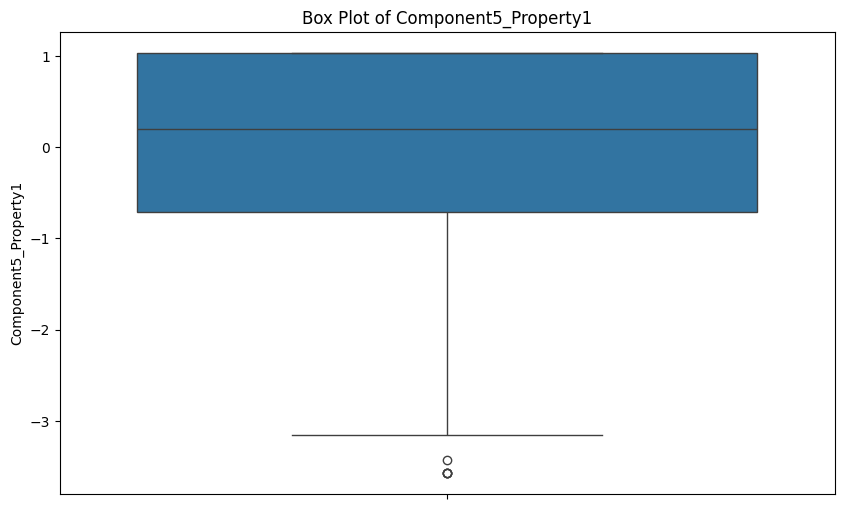

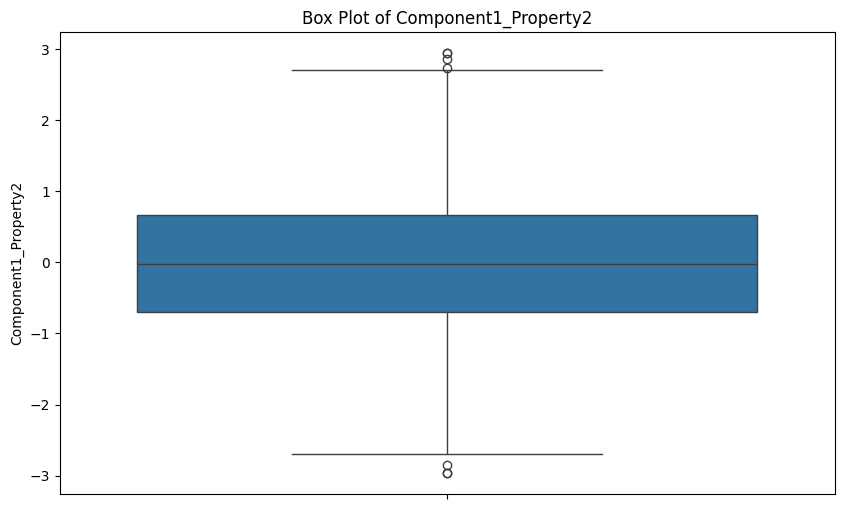

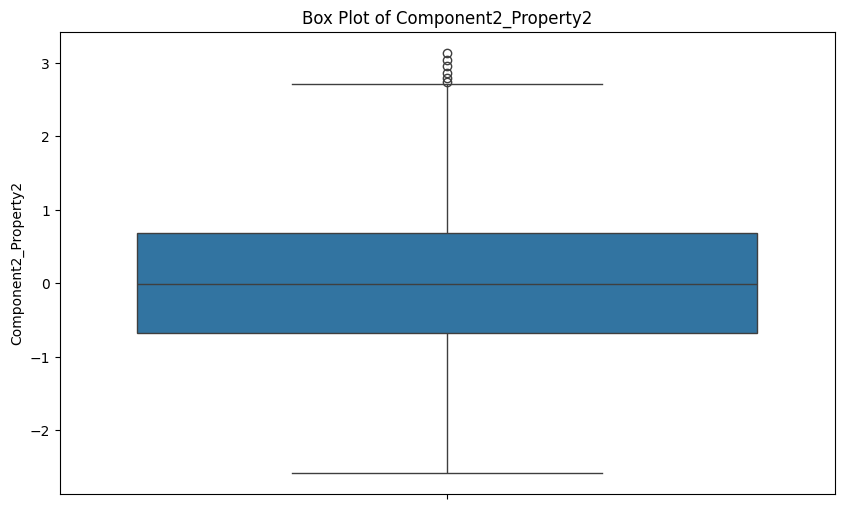

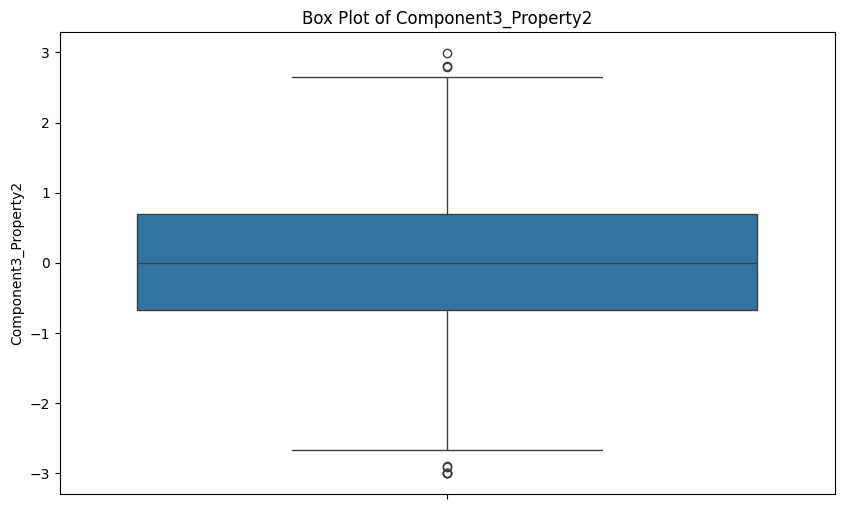

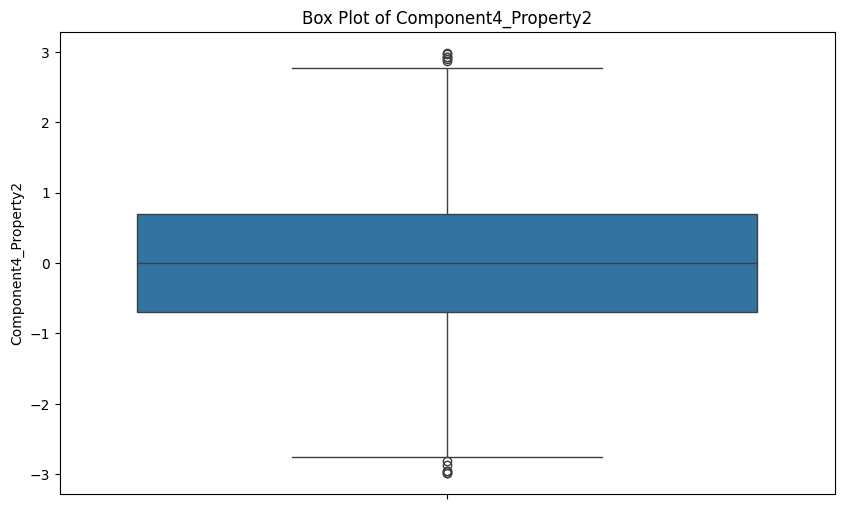

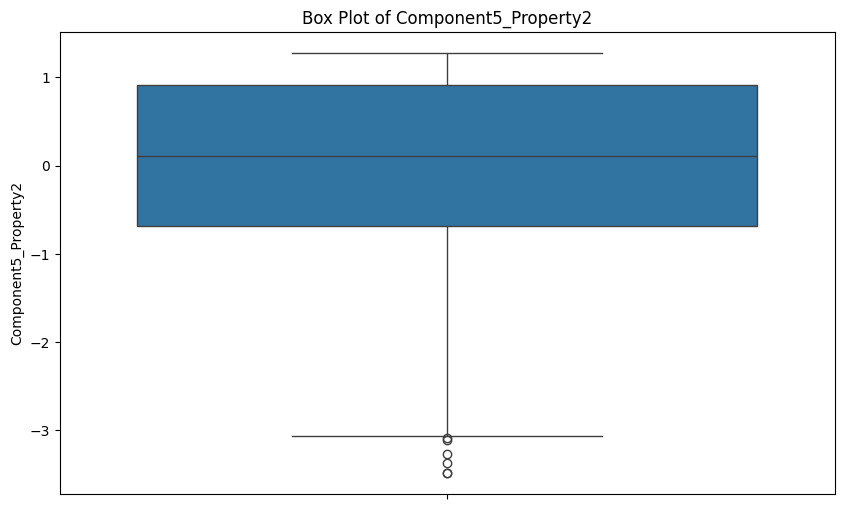

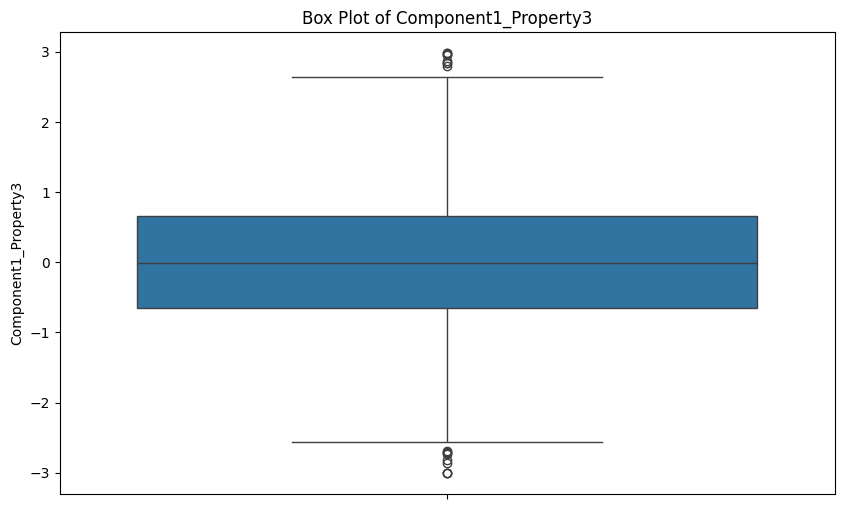

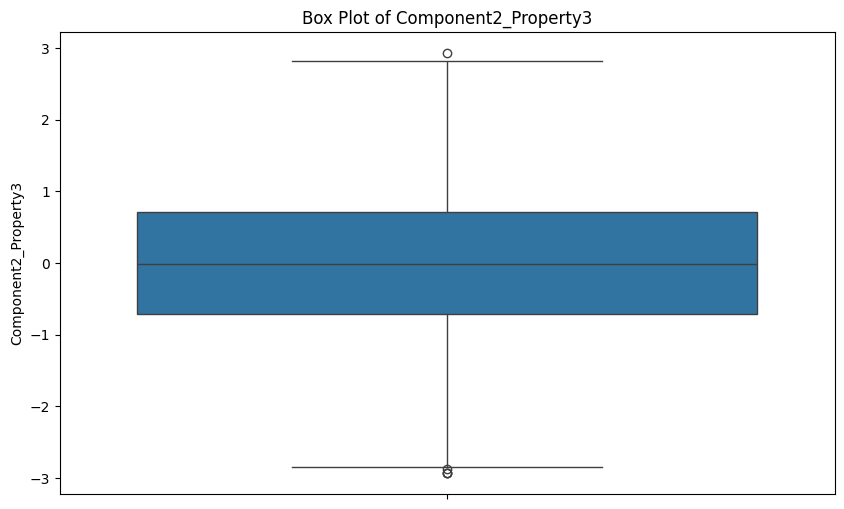

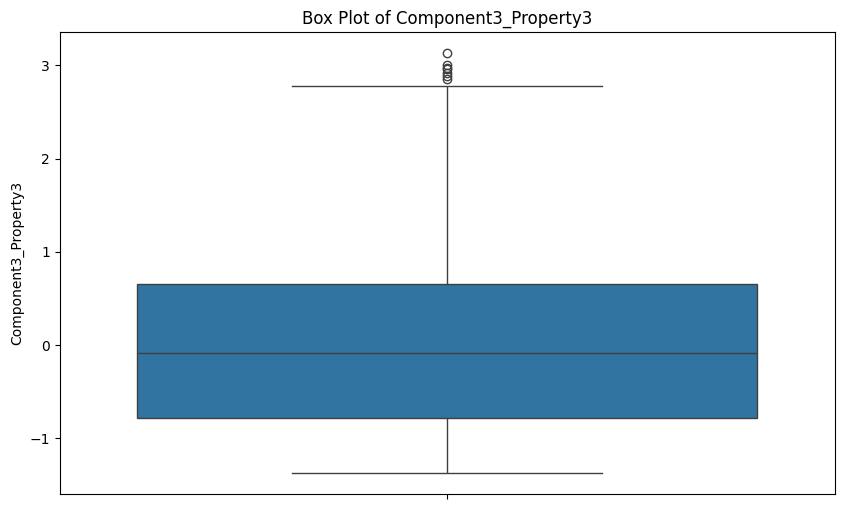

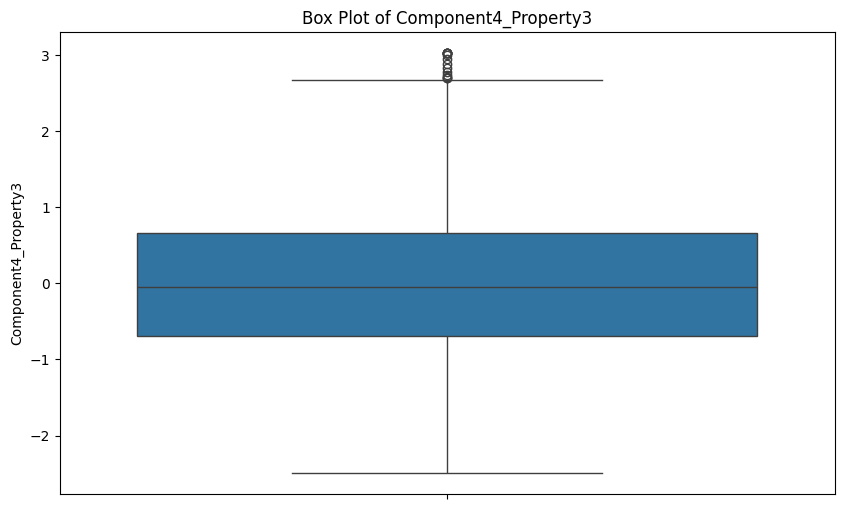

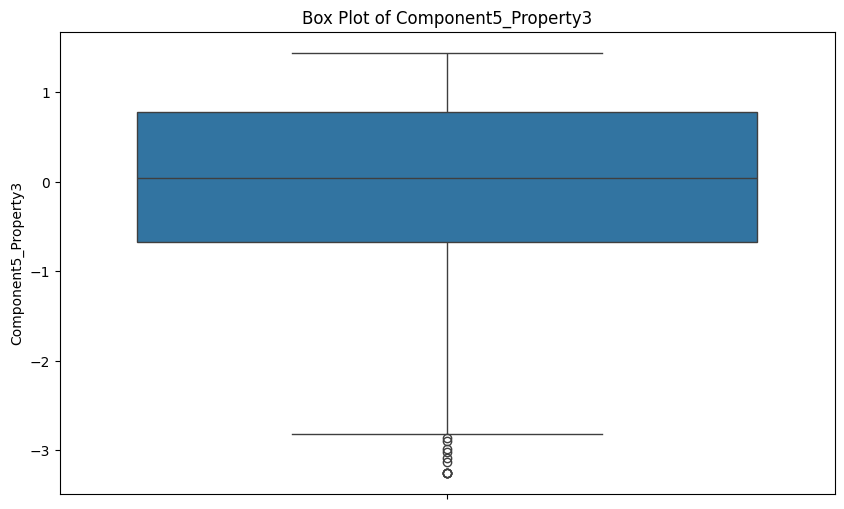

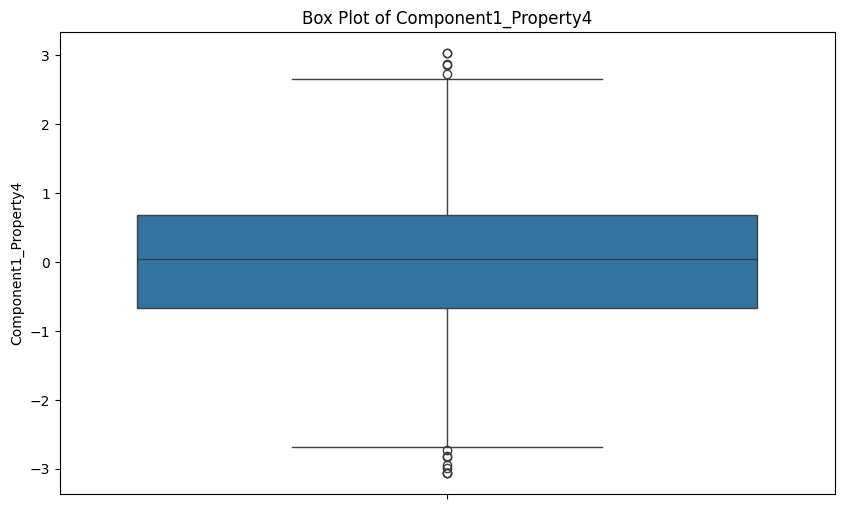

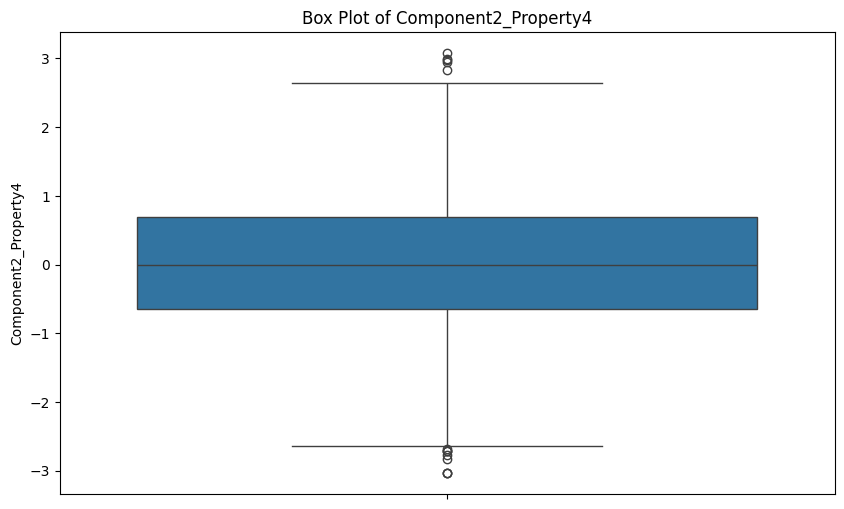

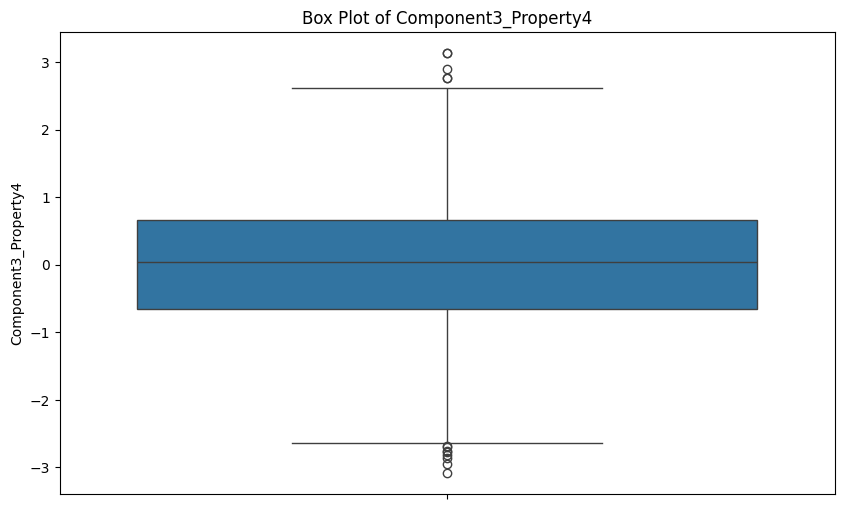

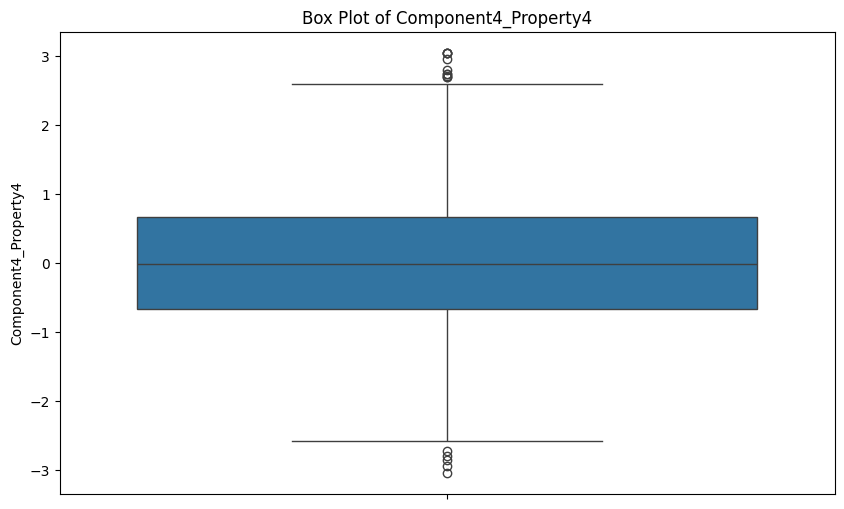

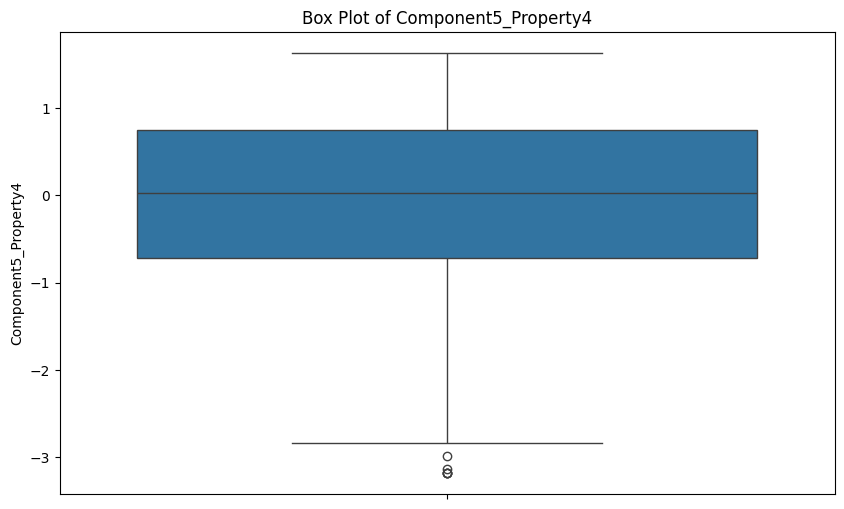

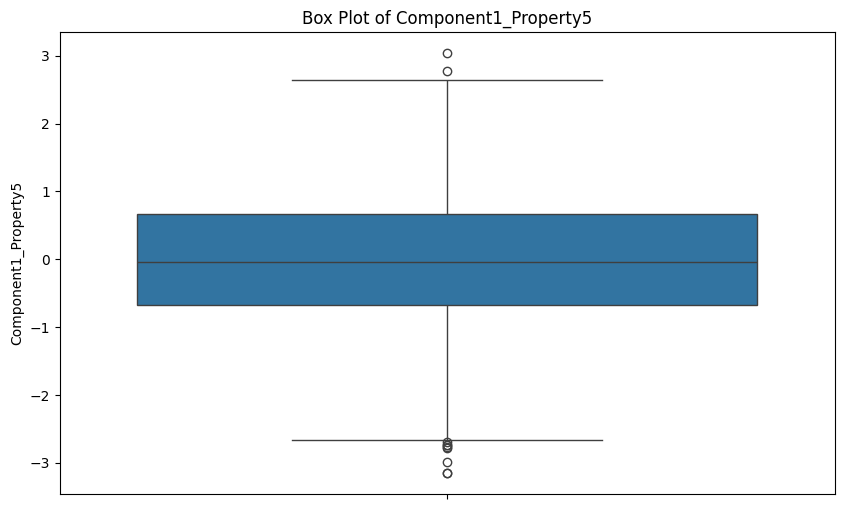

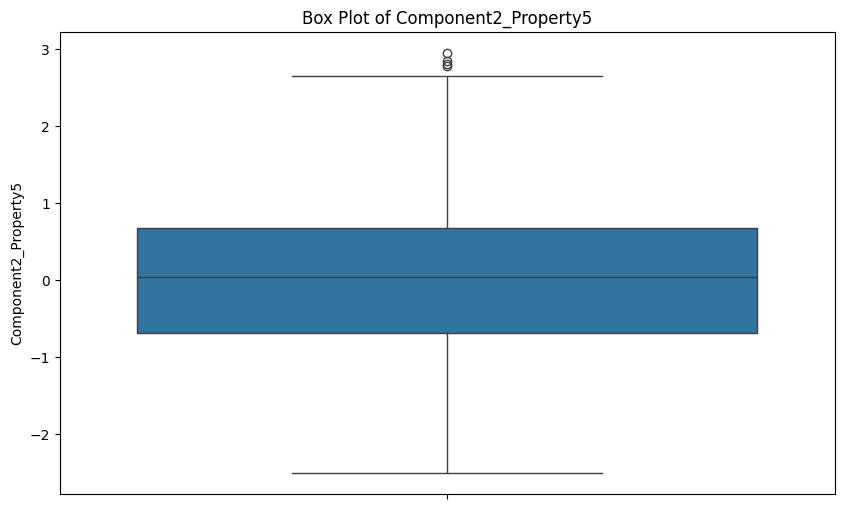

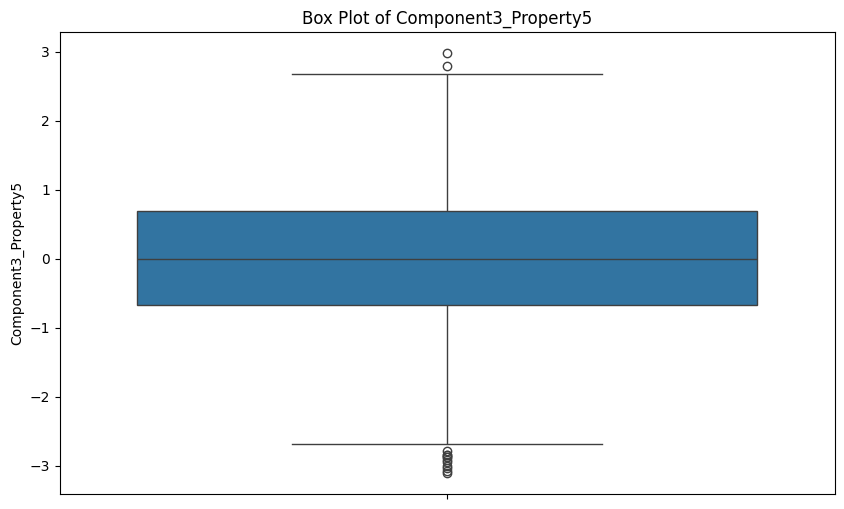

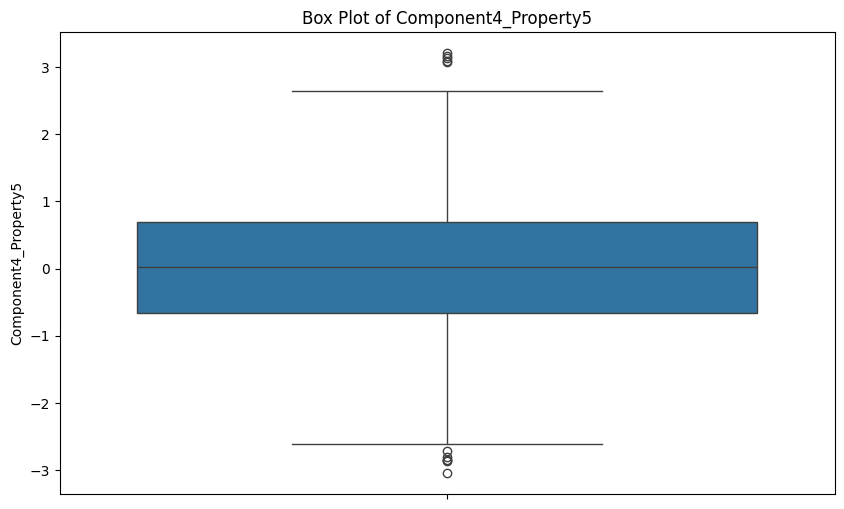

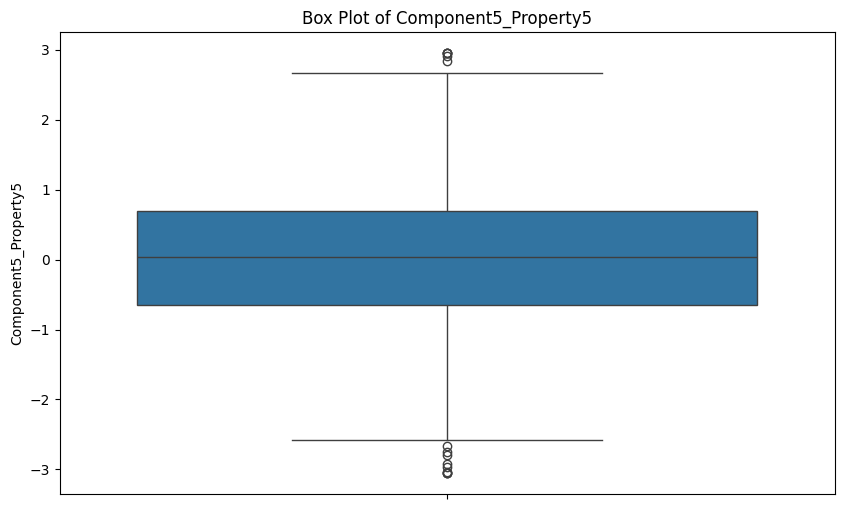

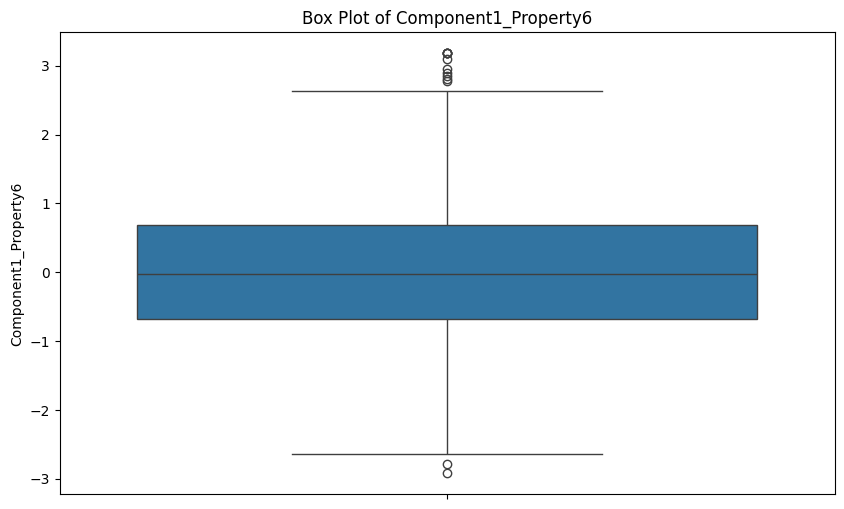

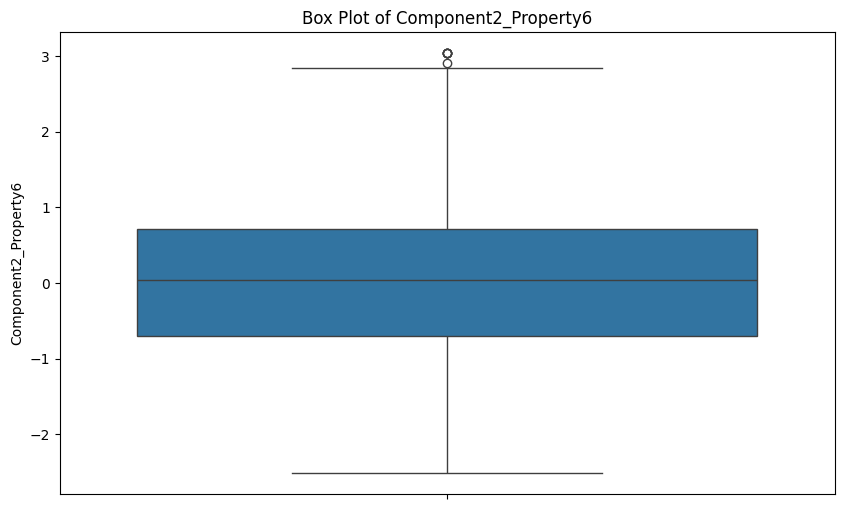

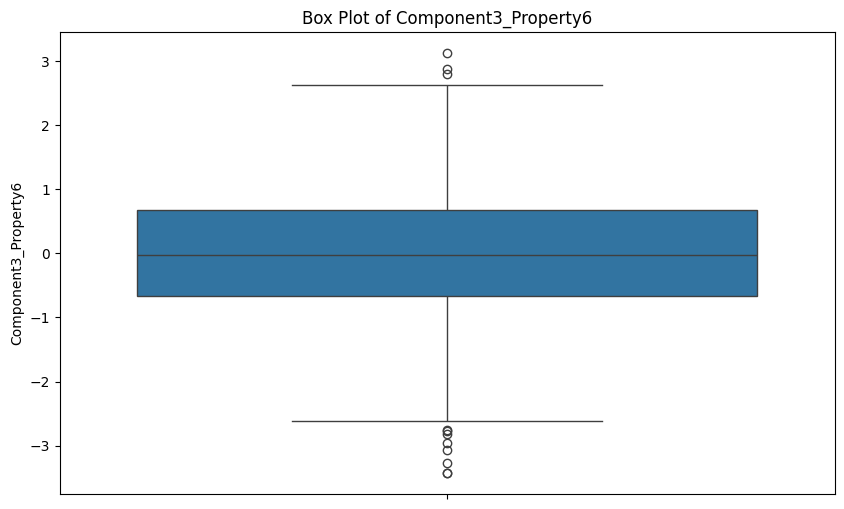

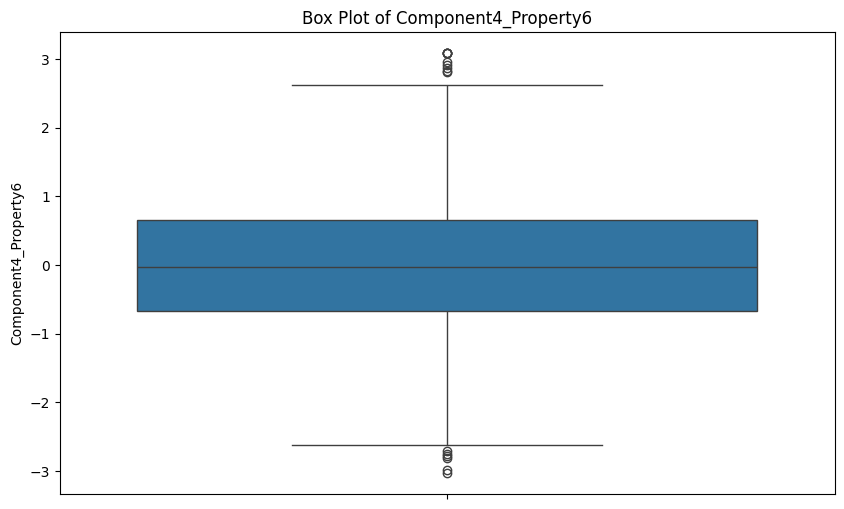

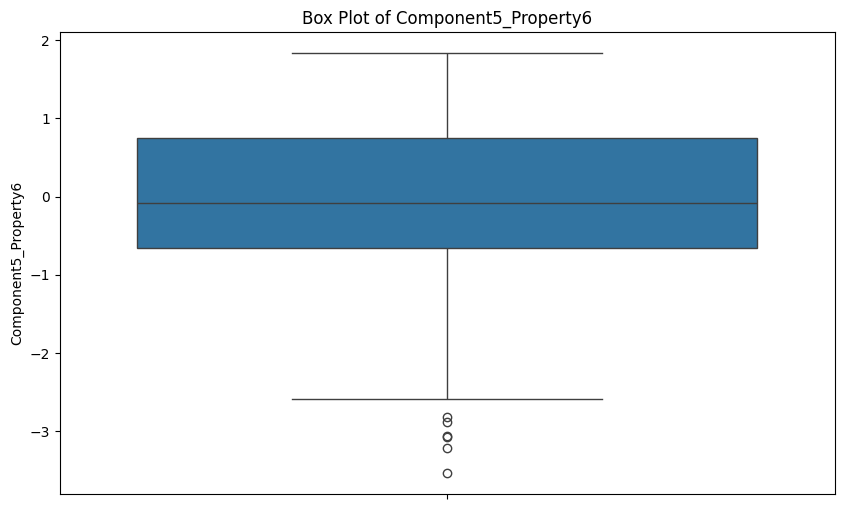

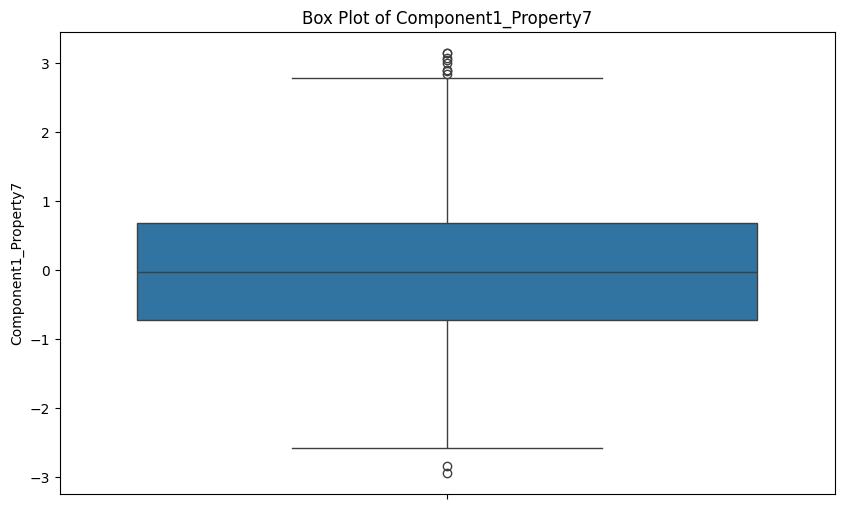

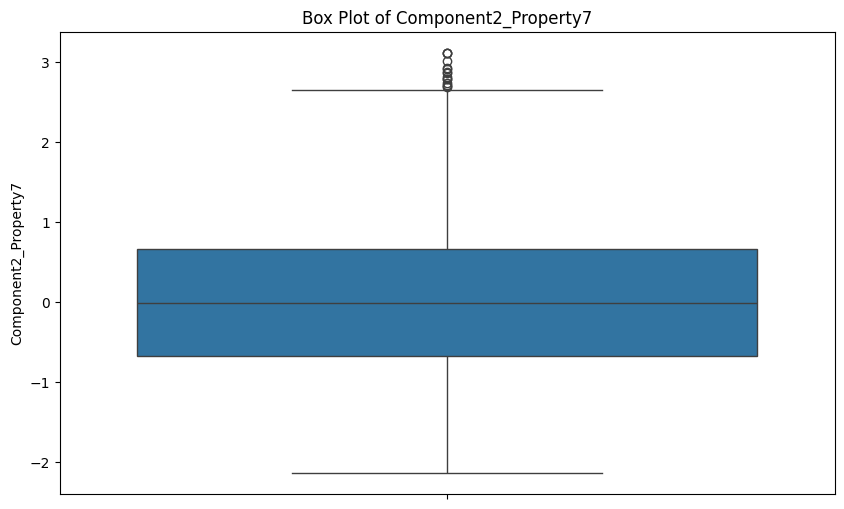

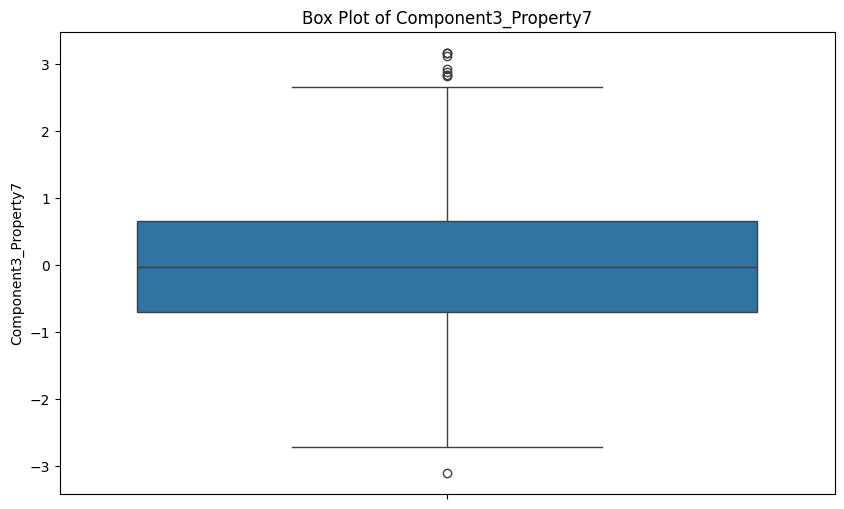

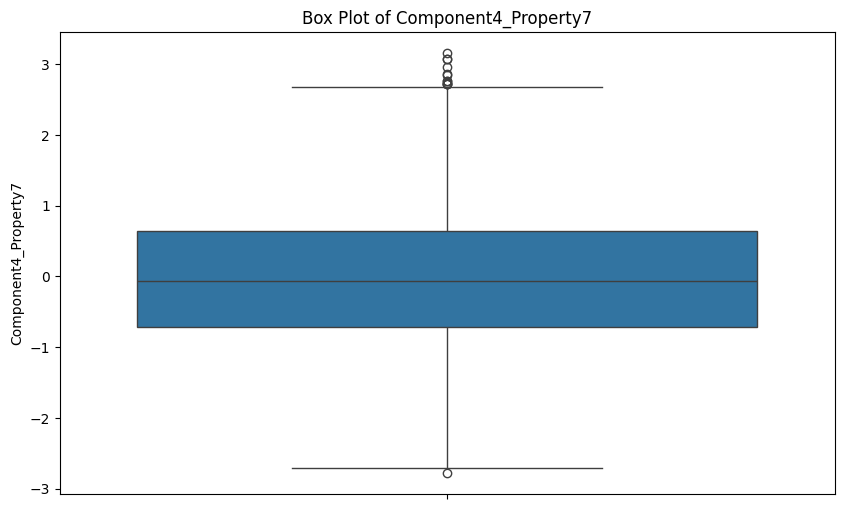

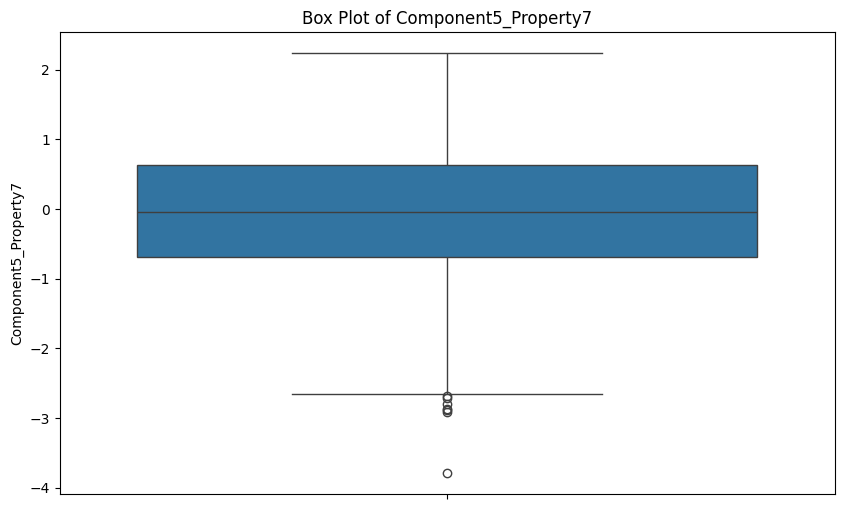

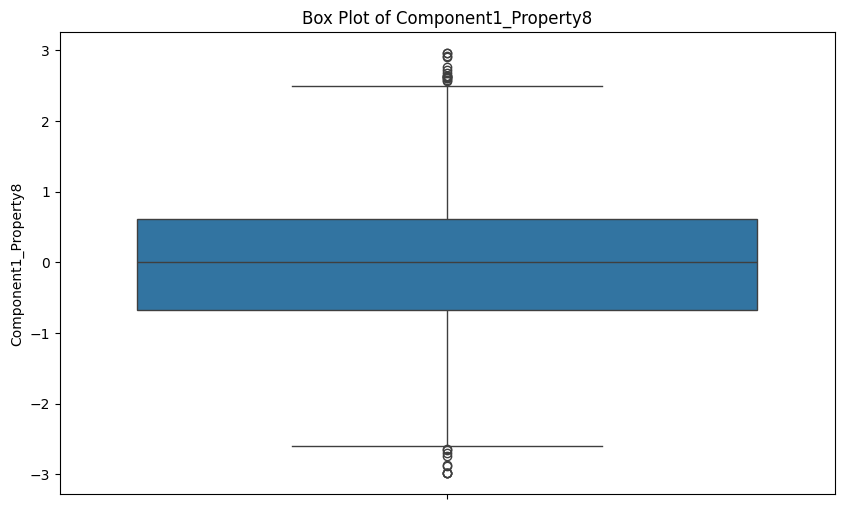

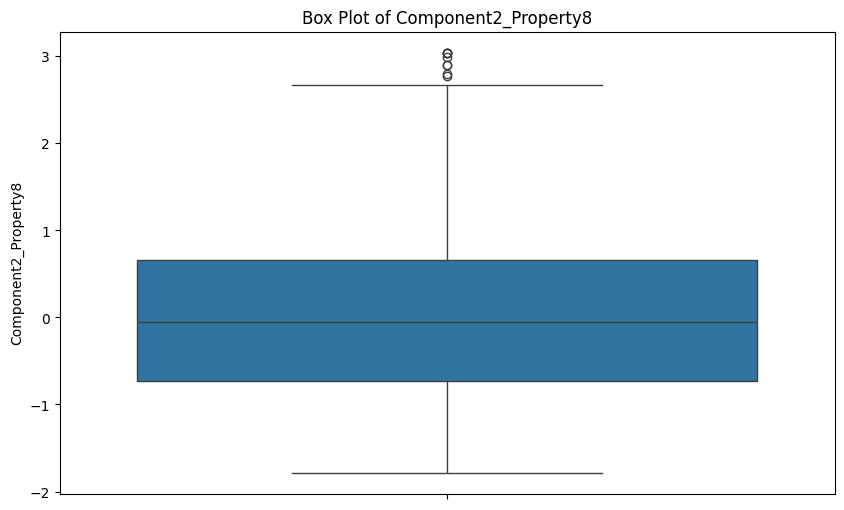

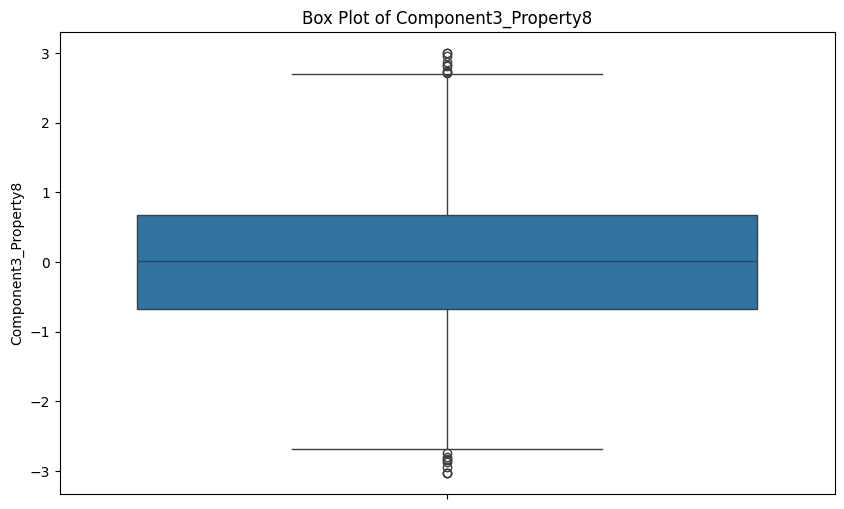

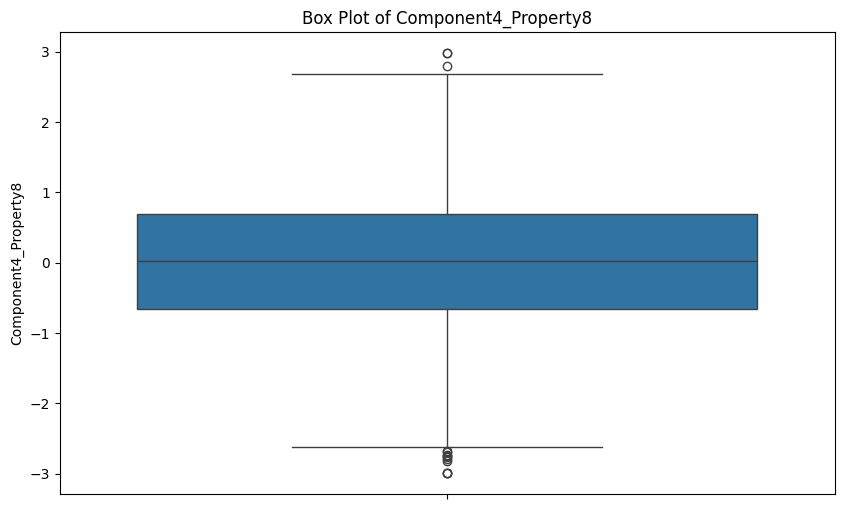

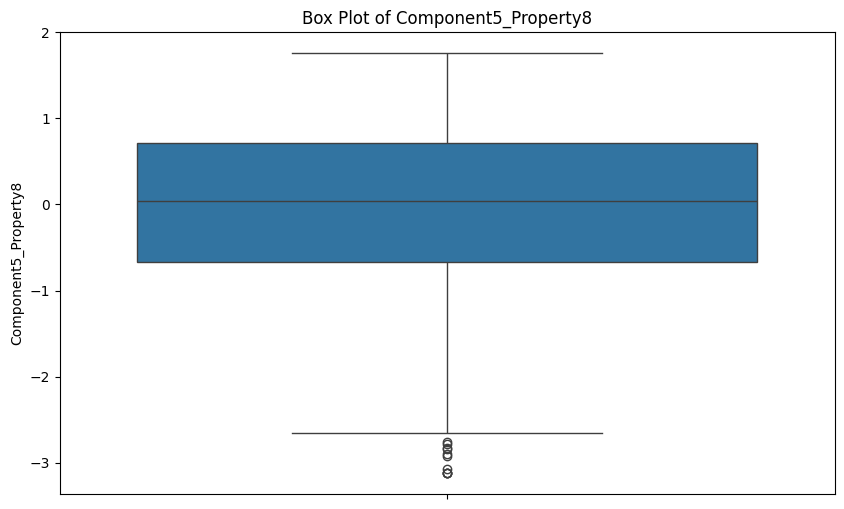

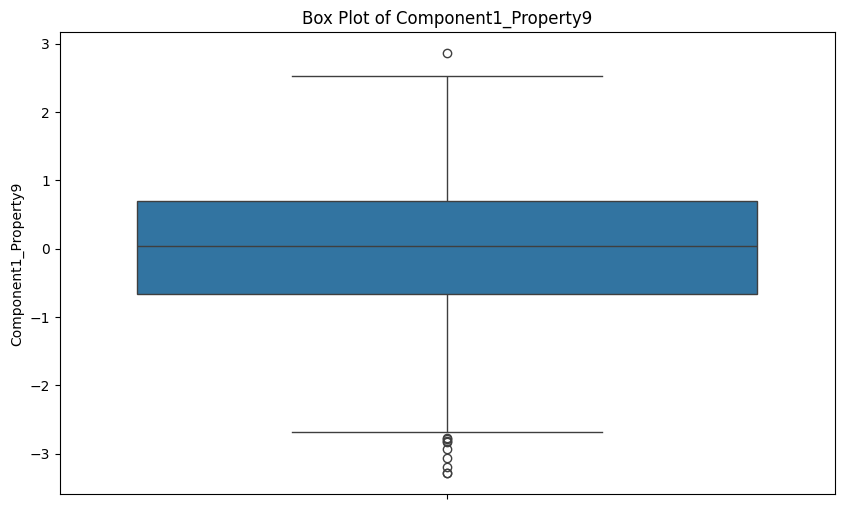

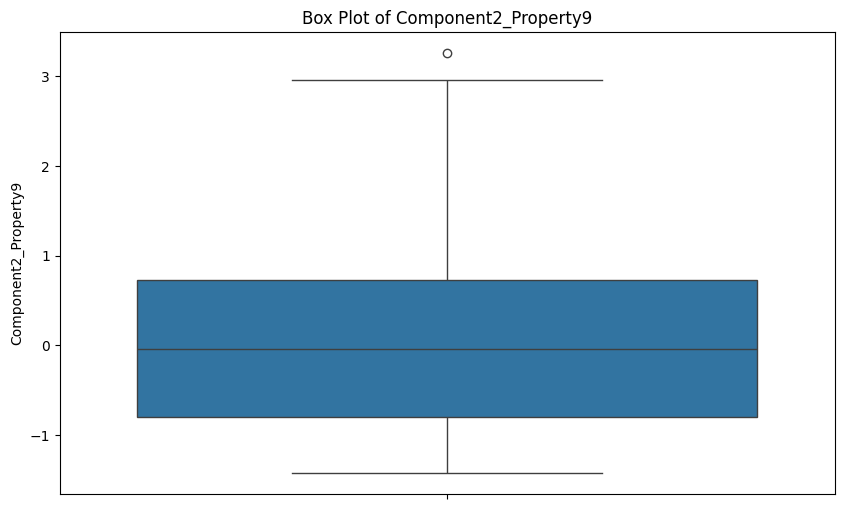

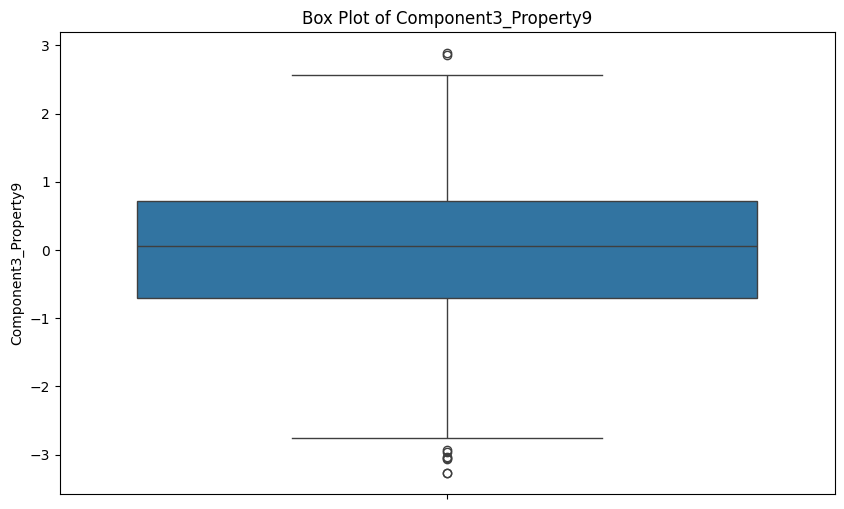

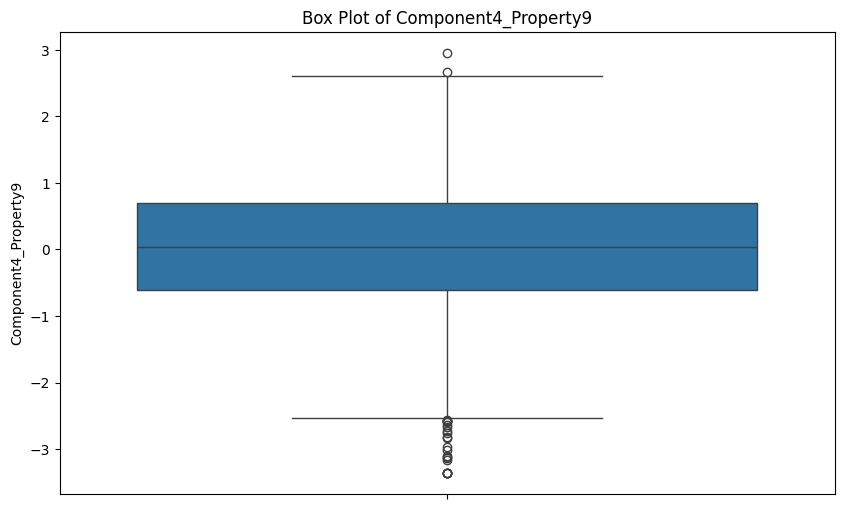

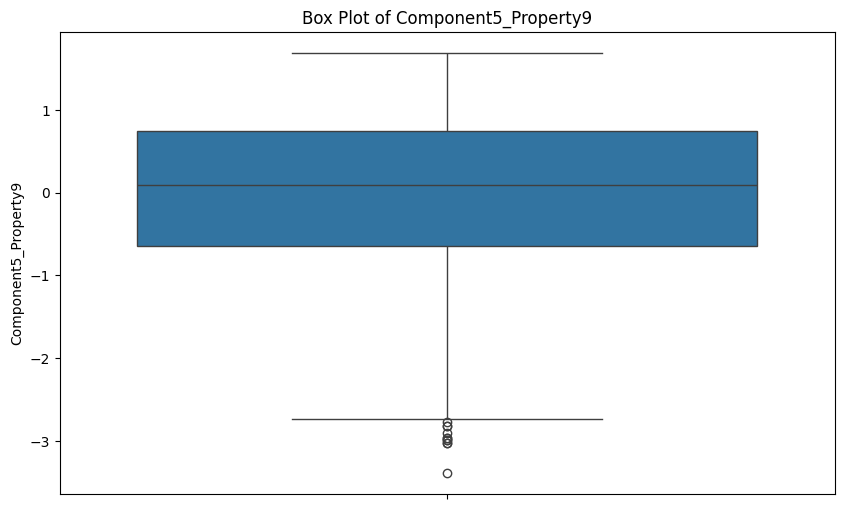

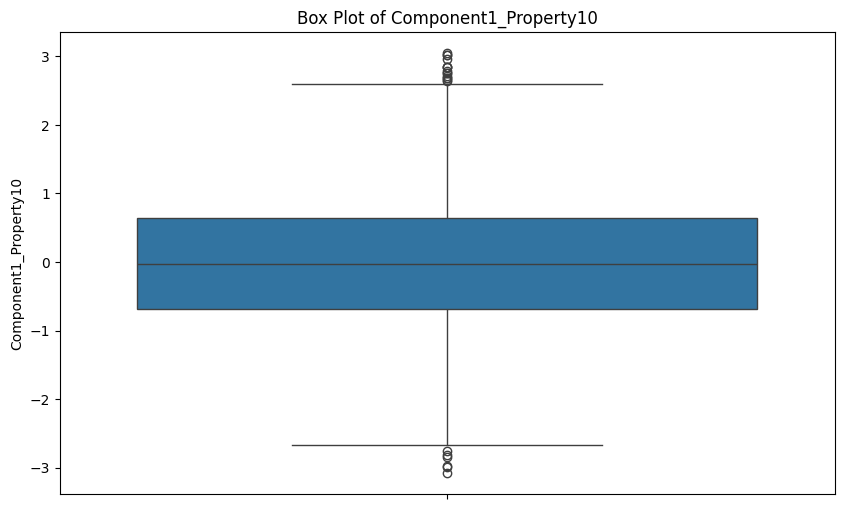

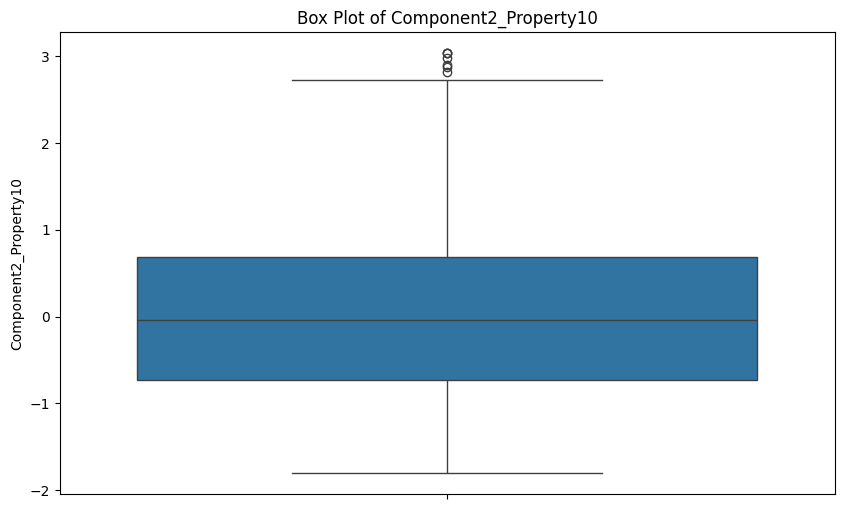

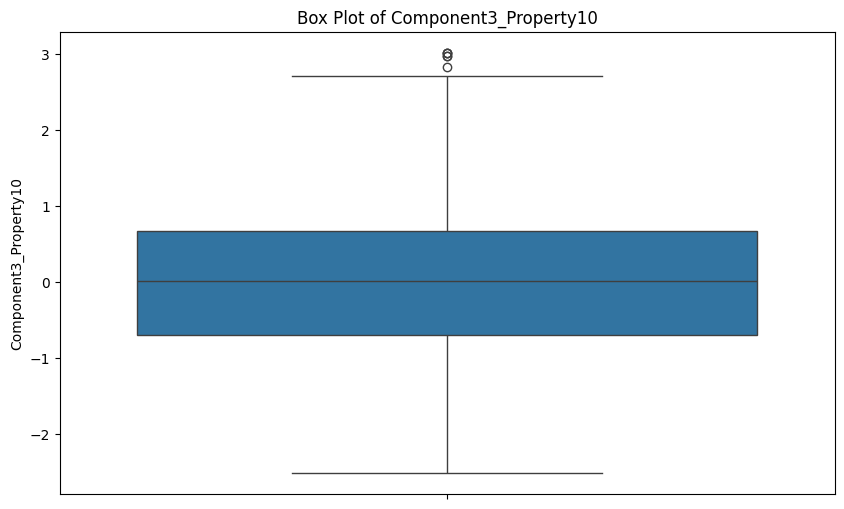

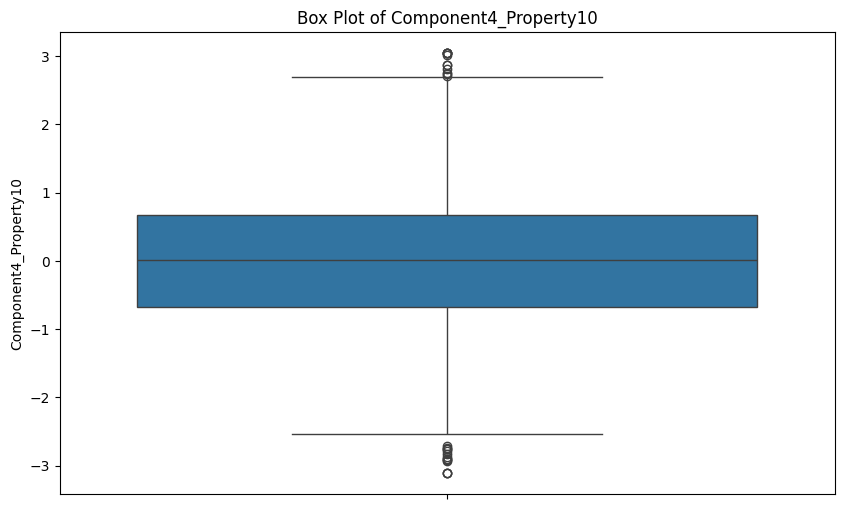

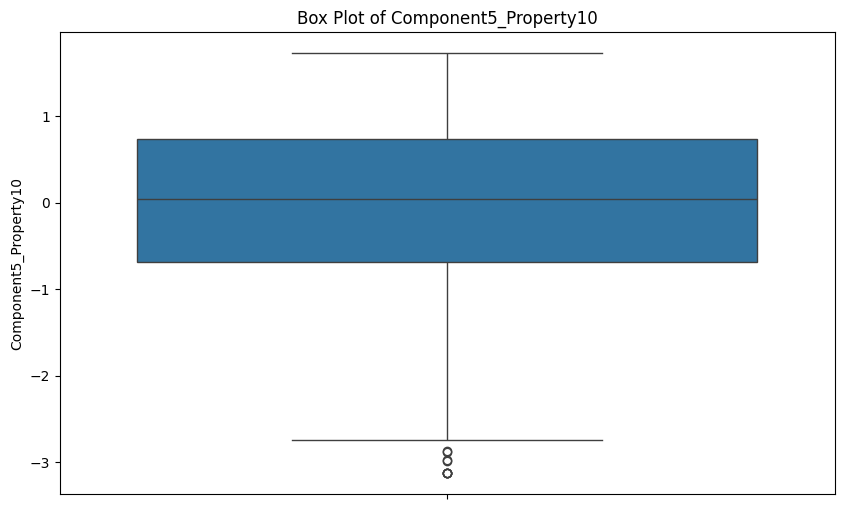

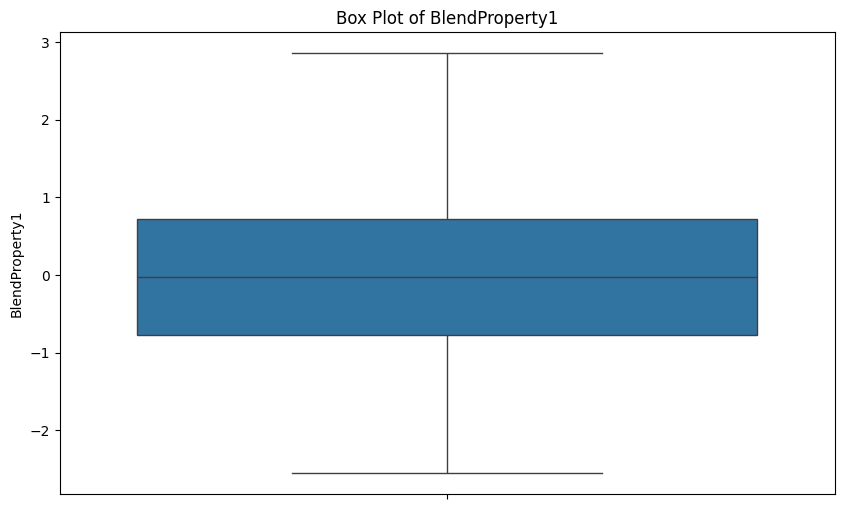

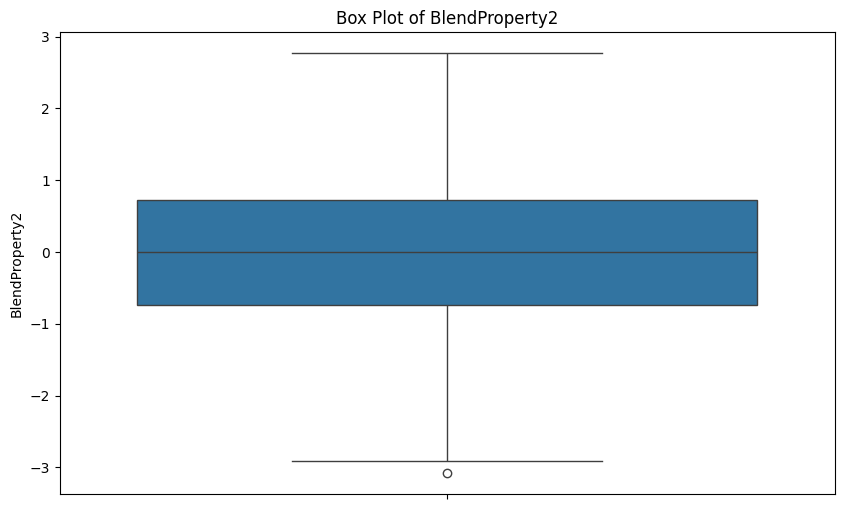

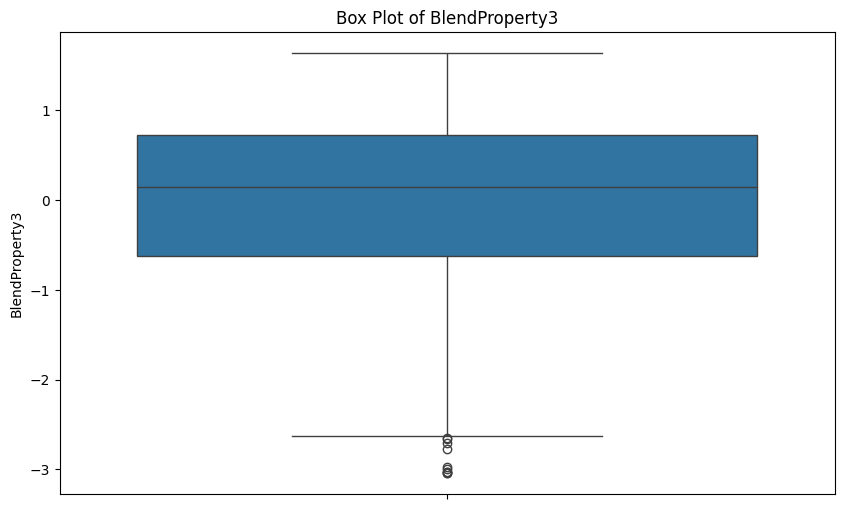

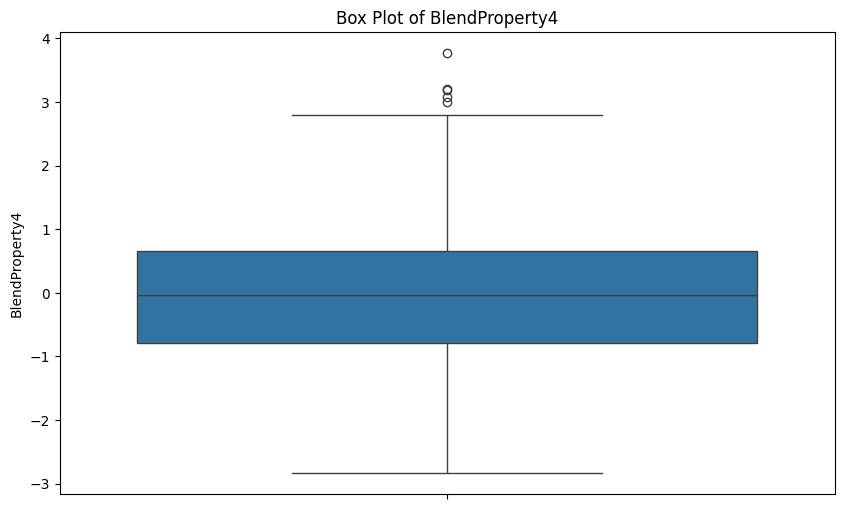

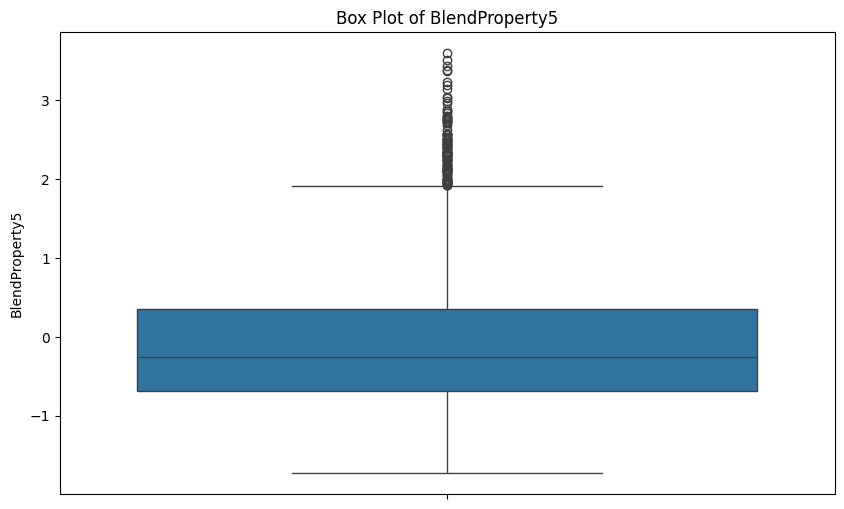

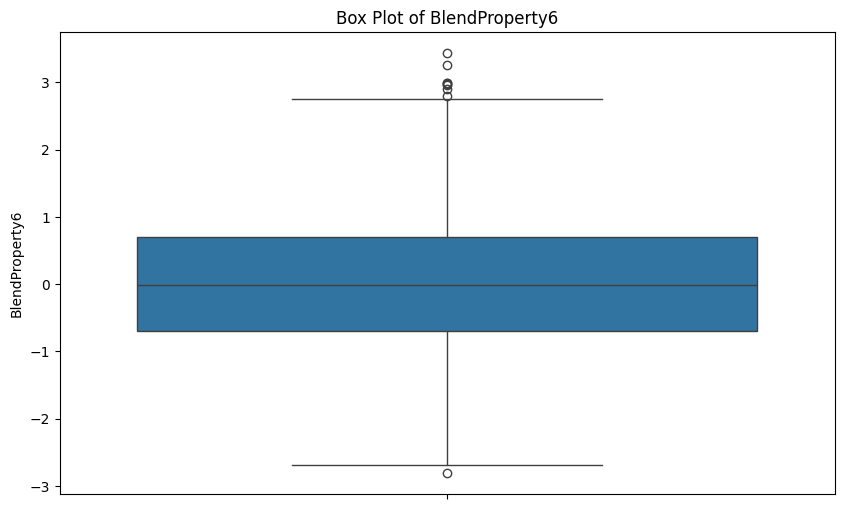

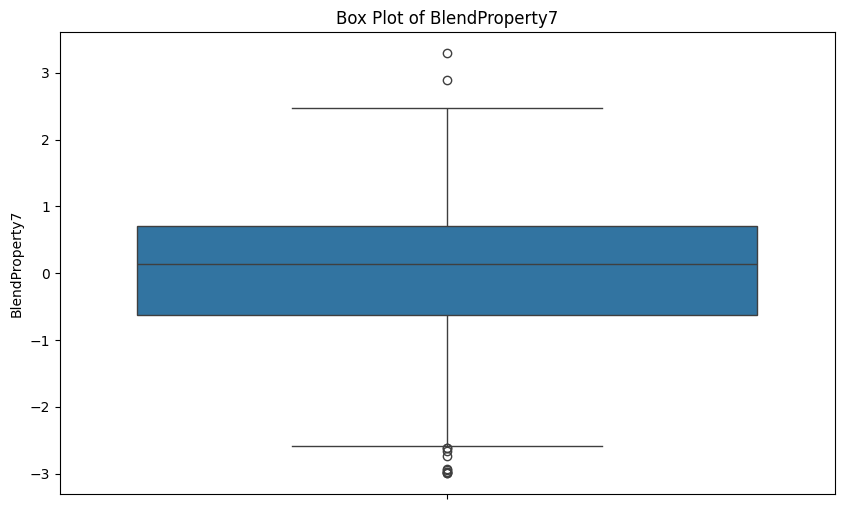

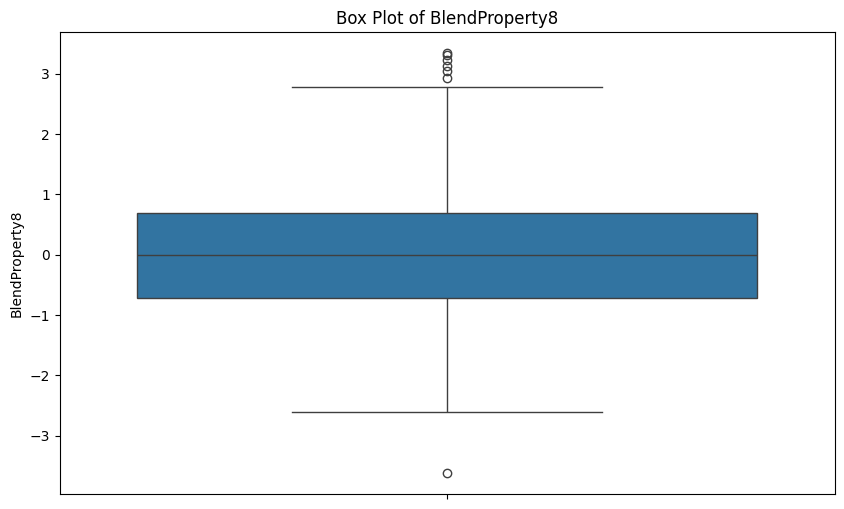

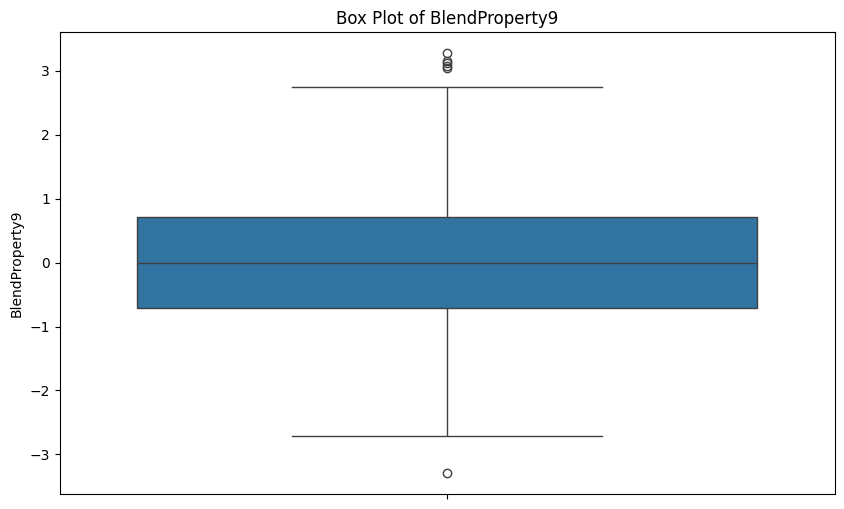

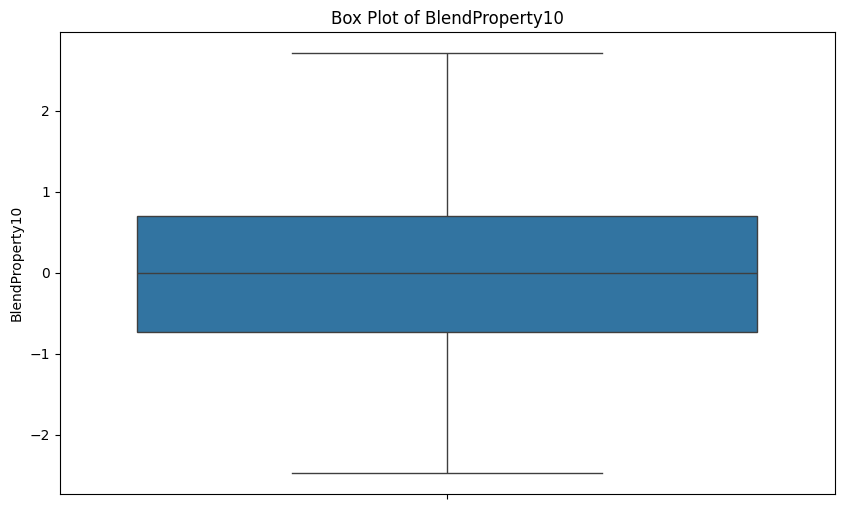

In [3]:
# Distribution of numerical features
numerical_features = train_df.select_dtypes(include=np.number).columns
for col in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.histplot(train_df[col].dropna(), kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

# Correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(train_df[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Box plots for outlier detection
for col in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(y=train_df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()


### Step 9: Advanced EDA
- Pair plots for variable relationships
- Distribution plots for each variable
- Scatter plots for key relationships
- Statistical summaries by groups if applicable



## Phase 5: Hypothesis Testing & Statistical Analysis

### Step 10: Hypothesis Testing
**Hypothesis 1**: Each substance has influence on other properties
- Test correlations for statistical significance
- Use appropriate tests (Pearson/Spearman based on distribution)
- Apply multiple testing corrections (Bonferroni, FDR)

**Hypothesis 2**: One property influences others
- Conduct causality analysis where possible
- Use regression analysis to test influence
- Consider time-series analysis if temporal data available



### Step 11: Principal Component Analysis (PCA)
- Determine if dimensionality reduction is needed
- Perform PCA on standardized data
- Analyze explained variance ratio
- Interpret principal components
- Decide on number of components to retain



## Phase 6: Modeling Strategy

### Step 12: Model Selection and Preparation
- Split data into train/validation/test sets
- Choose appropriate evaluation metrics
- Establish baseline performance



### Step 13: Linear Regression Models (10 Models)
Create 10 separate linear regression models:
- **Model 1-5**: One model for each of the 5 components
- **Model 6-10**: One model for each of the 5 main properties
- Use cross-validation for model evaluation
- Check assumptions (linearity, homoscedasticity, independence)



### Step 14: Neural Network Model
- Design architecture with final layer having 10 neurons
- Target: Mileage output
- Use appropriate activation functions
- Implement regularization (dropout, L1/L2)
- Monitor for overfitting



## Phase 7: Model Evaluation & Fine-tuning

### Step 15: Model Performance Evaluation
- Calculate performance metrics for all models
- Compare linear models vs neural network
- Analyze residuals and model assumptions
- Identify best performing models



### Step 16: Model Fine-tuning
- Hyperparameter optimization
- Feature selection/engineering
- Ensemble methods if appropriate
- Cross-validation for robust evaluation



## Phase 8: Final Analysis & Recommendations

### Step 17: Component Reduction Decision
Based on PCA and model performance:
- Decide if dimensionality reduction improves results
- Compare full model vs reduced model performance
- Consider interpretability vs accuracy trade-offs



### Step 18: Mutual Relationship Analysis
- Analyze how variables interact with each other
- Identify the most important relationships
- Create interaction terms if beneficial
- Document key insights



## Phase 9: Documentation & Reporting

### Step 19: Results Compilation
- Summarize key findings from each phase
- Document model performance comparisons
- Highlight most significant relationships
- Provide actionable insights



## Phase 9: Documentation & Reporting

### Step 19: Results Compilation
- Summarize key findings from each phase
- Document model performance comparisons
- Highlight most significant relationships
- Provide actionable insights



### Step 20: Final Recommendations
- Recommend best model(s) for prediction
- Suggest data collection improvements
- Provide guidelines for model deployment
- Document limitations and assumptions


## Overview


## Key Deliverables by Phase

### Phase 1-2: Data Quality Report
- COA validation results
- Data distribution summary
- Outlier analysis report

### Phase 3-4: Clean Dataset + EDA Report
- Processed, clean dataset
- Comprehensive correlation analysis
- Visual exploration results

### Phase 5: Statistical Analysis Report
- Hypothesis testing results
- PCA analysis and recommendations
- Component reduction strategy

### Phase 6-7: Model Performance Report
- 10 linear regression models
- Neural network model
- Performance comparison
- Fine-tuning results

### Phase 8-9: Final Analysis & Recommendations
- Component reduction decision
- Mutual relationship insights
- Deployment recommendations

## Priority Order Rationale

1. **COA Validation First**: Critical for data integrity
2. **Data Quality Before Analysis**: Clean data = reliable results
3. **EDA Before Modeling**: Understand data patterns first
4. **Statistical Tests Before Advanced Models**: Establish baseline understanding
5. **Multiple Models for Comparison**: Identify best approach
6. **Fine-tuning Last**: Optimize after understanding what works

This workflow ensures systematic, reproducible analysis while addressing all your requirements in logical sequence.